# 02D: Dynamic Cluster News Selector + XGBoost

本 Notebook 實作你要求的完整流程：
1. 以報酬相關性建立動態聚類（可重平衡）。
2. 以公司描述文字建立 NLP 同儕聚類。
3. 以目標股 / 同群股 / 宏觀三層新聞做動態篩選。
4. 用 TF-IDF 餘弦相似度過濾低關聯噪音新聞。
5. 用 FinBERT 打分並建構情緒特徵。
6. 比較 Baseline XGBoost vs News-Enhanced XGBoost。

## 設計重點與可調參數

- 動態聚類視窗：`RET_CLUSTER_WINDOW_DAYS=180`
- 動態重平衡頻率：`RET_REBALANCE_DAYS=20`
- 新聞回看天數：`NEWS_LOOKBACK_DAYS=10`
- 相關度門檻：`COSINE_MIN_SIM=0.08`
- 類別權重：Direct / Cluster / Macro 可獨立調整
- 可先用 5 檔快速驗證，再切全市場

In [53]:
%pip install -q numpy pandas scikit-learn xgboost yfinance kagglehub transformers torch

Note: you may need to restart the kernel to use updated packages.


In [41]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import yfinance as yf
import kagglehub
from transformers import pipeline

pd.set_option('display.max_colwidth', 120)
np.random.seed(42)

# =========================
# Config
# =========================
FAST_MODE = True
FAST_STOCKS = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']

RET_CLUSTER_WINDOW_DAYS = 180
RET_REBALANCE_DAYS = 20
RET_N_CLUSTERS = 8
NLP_N_CLUSTERS = 8

NEWS_LOOKBACK_DAYS = 10
COSINE_MIN_SIM = 0.08

WEIGHT_DIRECT = 1.0
WEIGHT_CLUSTER = 0.7
WEIGHT_MACRO = 0.6

MACRO_KEYWORDS = [
    'fed', 'federal reserve', 'inflation', 'interest rate',
    's&p 500', 'sp500', 'cpi', 'fomc', 'treasury', 'recession',
]

print('[OK] Config loaded')

[OK] Config loaded


In [42]:
# =========================
# Path + Data Loading
# =========================
cwd = Path.cwd()

if cwd.name == 'implementation' and cwd.parent.name == '02_stock_price_regression':
    reg_root = cwd.parent
elif cwd.name == '02_stock_price_regression':
    reg_root = cwd
elif (cwd / 'project_folder' / '02_stock_price_regression').exists():
    reg_root = cwd / 'project_folder' / '02_stock_price_regression'
else:
    reg_root = cwd

workspace_root = reg_root.parent
data_dir = reg_root / 'data'
data_dir.mkdir(parents=True, exist_ok=True)
graph_dir = reg_root / 'graph'
graph_dir.mkdir(parents=True, exist_ok=True)

news_raw_path = workspace_root / 'news_data' / 'data' / 'news_headlines_raw.csv'

cluster_data_dir = workspace_root / '03_stock_clustering_analysis' / 'data'
reg_data_dir = reg_root / 'data'
price_candidates = [
    cluster_data_dir / 'sp500_raw.csv',
    reg_data_dir / 'sp500_raw.csv',
    reg_data_dir / '02C_sp500_raw.csv',
    reg_data_dir / '02B_sp500_raw.csv',
]

price_path = next((p for p in price_candidates if p.exists()), None)
if price_path is None:
    print('[INFO] Shared price cache not found, downloading Kaggle S&P500 data...')
    kaggle_path = kagglehub.dataset_download('camnugent/sandp500')
    csv_file = [f for f in os.listdir(kaggle_path) if f.endswith('.csv')][0]
    price_df = pd.read_csv(os.path.join(kaggle_path, csv_file))
else:
    price_df = pd.read_csv(price_path)

if not news_raw_path.exists():
    raise FileNotFoundError(f'Missing shared news file: {news_raw_path}')

news_df = pd.read_csv(news_raw_path)

required_price_cols = {'Name', 'date', 'close', 'open', 'high', 'low', 'volume'}
missing_price = required_price_cols - set(price_df.columns)
if missing_price:
    raise ValueError(f'Price data missing required columns: {sorted(missing_price)}')

required_news_cols = {'Name', 'date', 'headline', 'source'}
missing_news = required_news_cols - set(news_df.columns)
if missing_news:
    raise ValueError(f'News data missing required columns: {sorted(missing_news)}')

price_df = price_df.copy()
price_df['Name'] = price_df['Name'].astype(str).str.strip()
price_df['date'] = pd.to_datetime(price_df['date'], errors='coerce').dt.normalize()
price_df = price_df.dropna(subset=['Name', 'date']).sort_values(['Name', 'date']).reset_index(drop=True)

news_df = news_df.copy()
news_df['Name'] = news_df['Name'].astype(str).str.strip()
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce').dt.normalize()
news_df['headline'] = news_df['headline'].astype(str).str.strip()
news_df['source'] = news_df['source'].astype(str).str.lower().str.strip()
news_df = news_df.dropna(subset=['Name', 'date', 'headline']).reset_index(drop=True)

all_symbols = sorted(price_df['Name'].unique().tolist())
if FAST_MODE:
    symbols = [s for s in FAST_STOCKS if s in set(all_symbols)]
else:
    symbols = all_symbols

price_df = price_df[price_df['Name'].isin(symbols)].copy()
news_df = news_df[news_df['Name'].isin(symbols)].copy()

print(f'Price rows: {len(price_df):,}')
print(f'News rows: {len(news_df):,}')
print(f'Symbols: {len(symbols)} -> {symbols[:10]}')

Price rows: 6,011
News rows: 240
Symbols: 5 -> ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']


In [43]:
# =========================
# Step 1A: Return Correlation Dynamic Clustering
# =========================
close_px = price_df.pivot(index='date', columns='Name', values='close').sort_index()
ret_px = close_px.pct_change()
rebalance_dates = close_px.index[RET_CLUSTER_WINDOW_DAYS::RET_REBALANCE_DAYS]

dynamic_cluster_rows = []

for rb_date in rebalance_dates:
    window_start = rb_date - pd.Timedelta(days=RET_CLUSTER_WINDOW_DAYS)
    window_ret = ret_px[(ret_px.index > window_start) & (ret_px.index <= rb_date)]

    if len(window_ret) < 30:
        continue

    corr = window_ret.corr(min_periods=20)
    corr = corr.fillna(0.0)

    valid_symbols = corr.index.tolist()
    X = corr.values

    n_clusters = min(RET_N_CLUSTERS, max(2, len(valid_symbols) // 2))
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    labels = km.fit_predict(X)

    for s, c in zip(valid_symbols, labels):
        dynamic_cluster_rows.append({
            'rebalance_date': rb_date,
            'Name': s,
            'ret_cluster': int(c)
        })

ret_cluster_df = pd.DataFrame(dynamic_cluster_rows)

if len(ret_cluster_df) == 0:
    # Fallback: one-shot clustering on full period correlation
    full_corr = ret_px.corr(min_periods=20).fillna(0.0)
    valid_symbols = full_corr.index.tolist()
    n_clusters = min(RET_N_CLUSTERS, max(2, len(valid_symbols) // 2))
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    labels = km.fit_predict(full_corr.values)

    rb_date = close_px.index.max()
    ret_cluster_df = pd.DataFrame({
        'rebalance_date': [rb_date] * len(valid_symbols),
        'Name': valid_symbols,
        'ret_cluster': labels.astype(int)
    })

ret_cluster_df = ret_cluster_df.sort_values(['rebalance_date', 'Name']).reset_index(drop=True)
display(ret_cluster_df.head(10))
n_snapshots = ret_cluster_df['rebalance_date'].nunique()
print(f'Return-cluster snapshots: {n_snapshots}')

,rebalance_date,Name,ret_cluster
0,2013-10-25,AAPL,0
1,2013-10-25,AMZN,1
2,2013-10-25,GOOG,0
3,2013-10-25,MSFT,1
4,2013-10-25,NVDA,1
5,2013-11-22,AAPL,0
6,2013-11-22,AMZN,1
7,2013-11-22,GOOG,0
8,2013-11-22,MSFT,1
9,2013-11-22,NVDA,1


Return-cluster snapshots: 54


In [44]:
# =========================
# Step 1B: NLP-based Sector/Peer Clustering
# =========================
profile_cache_path = data_dir / '02D_company_profile_cache.csv'

if profile_cache_path.exists():
    profile_df = pd.read_csv(profile_cache_path)
else:
    profile_rows = []
    for s in symbols:
        text = ''
        try:
            info = yf.Ticker(s.replace('.', '-')).info
            text = str(info.get('longBusinessSummary', '') or '')
        except Exception:
            text = ''

        if not text.strip():
            text = f'{s} company in S&P 500'

        profile_rows.append({'Name': s, 'profile_text': text})

    profile_df = pd.DataFrame(profile_rows)
    profile_df.to_csv(profile_cache_path, index=False)

vectorizer_profile = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), stop_words='english')
X_profile = vectorizer_profile.fit_transform(profile_df['profile_text'].astype(str).tolist())

nlp_n_clusters = min(NLP_N_CLUSTERS, max(2, len(profile_df) // 2))
km_profile = KMeans(n_clusters=nlp_n_clusters, random_state=42, n_init=20)
profile_df['nlp_cluster'] = km_profile.fit_predict(X_profile).astype(int)

display(profile_df.head(10))
print(f"NLP clusters: {profile_df['nlp_cluster'].nunique()}")

,Name,profile_text,nlp_cluster
0,AAPL,"Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories w...",1
1,MSFT,"Microsoft Corporation develops and supports software, services, devices, and solutions worldwide. The Productivity a...",0
2,GOOG,"Alphabet Inc. offers various products and platforms in the United States, Europe, the Middle East, Africa, the Asia-...",0
3,AMZN,"Amazon.com, Inc. engages in the retail sale of consumer products, advertising, and subscriptions service through onl...",1
4,NVDA,NVIDIA Corporation operates as a data center scale AI infrastructure company. The company operates through two segme...,1


NLP clusters: 2


In [45]:
# =========================
# Step 1C: Expand Dynamic Cluster Map to Daily
# =========================
all_dates = sorted(price_df['date'].dropna().unique().tolist())
all_dates_df = pd.DataFrame({'date': pd.to_datetime(all_dates)})

daily_cluster_rows = []
for s in symbols:
    s_snap = ret_cluster_df[ret_cluster_df['Name'] == s][['rebalance_date', 'ret_cluster']].sort_values('rebalance_date')
    if len(s_snap) == 0:
        continue

    merged = all_dates_df.merge(
        s_snap.rename(columns={'rebalance_date': 'date'}),
        on='date',
        how='left'
    ).sort_values('date')

    merged['ret_cluster'] = merged['ret_cluster'].ffill().bfill()
    merged['Name'] = s

    daily_cluster_rows.append(merged[['date', 'Name', 'ret_cluster']])

daily_cluster_df = pd.concat(daily_cluster_rows, ignore_index=True)
daily_cluster_df = daily_cluster_df.merge(profile_df[['Name', 'nlp_cluster']], on='Name', how='left')

# final_cluster 先以 ret_cluster 為主，nlp_cluster 作為補充特徵
daily_cluster_df['final_cluster'] = daily_cluster_df['ret_cluster'].astype(int)

display(daily_cluster_df.head(10))

,date,Name,ret_cluster,nlp_cluster,final_cluster
0,2013-02-08,AAPL,0.0,1,0
1,2013-02-11,AAPL,0.0,1,0
2,2013-02-12,AAPL,0.0,1,0
3,2013-02-13,AAPL,0.0,1,0
4,2013-02-14,AAPL,0.0,1,0
5,2013-02-15,AAPL,0.0,1,0
6,2013-02-19,AAPL,0.0,1,0
7,2013-02-20,AAPL,0.0,1,0
8,2013-02-21,AAPL,0.0,1,0
9,2013-02-22,AAPL,0.0,1,0


In [46]:
# =========================
# Step 2: News Selector + TF-IDF Relevance Filter
# =========================
news_df = news_df.copy()
news_df['headline_lc'] = news_df['headline'].astype(str).str.lower()

vectorizer_news = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
news_tfidf = vectorizer_news.fit_transform(news_df['headline'].astype(str).tolist())

news_df = news_df.reset_index(drop=True)
news_idx_by_date = news_df.groupby('date').indices

source_weight = {'yfinance': 0.90, 'google_rss': 1.00, 'newsapi': 1.00, 'unknown': 0.80}

def classify_news_type(row_name, row_headline_lc, peer_set):
    is_direct = row_name in peer_set
    macro_hit = any(k in row_headline_lc for k in MACRO_KEYWORDS)

    if is_direct:
        return 'direct'
    if macro_hit:
        return 'macro'
    return 'cluster'

def recency_weight(days_ago, half_life=3.0):
    return float(np.exp(-np.log(2) * days_ago / half_life))

def type_weight(news_type):
    if news_type == 'direct':
        return WEIGHT_DIRECT
    if news_type == 'cluster':
        return WEIGHT_CLUSTER
    return WEIGHT_MACRO

# 預先建立 cluster -> 成員查表，按 date 使用
cluster_member_map = {}
for dt, g in daily_cluster_df.groupby('date'):
    member = {}
    for cid, gg in g.groupby('final_cluster'):
        member[int(cid)] = set(gg['Name'].astype(str).tolist())
    cluster_member_map[pd.Timestamp(dt)] = member

In [47]:
# =========================
# Step 3: FinBERT Scoring + Cluster Sentiment Aggregation
# =========================
print('[INFO] Loading FinBERT pipeline...')
sent_pipe = pipeline('sentiment-analysis', model='ProsusAI/finbert', truncation=True)

macro_pattern = '|'.join([k.replace(' ', '\\s+') for k in MACRO_KEYWORDS])

def finbert_to_score(label, score):
    m = str(label).lower()
    s = float(score)
    if 'positive' in m:
        return s
    if 'negative' in m:
        return -s
    return 0.0

# headline score cache，避免重複推論
headline_cache_path = data_dir / '02D_headline_sentiment_cache.csv'
if headline_cache_path.exists():
    cache_df = pd.read_csv(headline_cache_path)
    sentiment_cache = dict(zip(cache_df['headline'], cache_df['sentiment_raw']))
else:
    sentiment_cache = {}

def get_sentiment_scores(headlines):
    out = []
    to_infer = []
    idx_map = []

    for i, h in enumerate(headlines):
        if h in sentiment_cache:
            out.append(sentiment_cache[h])
        else:
            out.append(None)
            to_infer.append(h)
            idx_map.append(i)

    if len(to_infer) > 0:
        batch_size = 32
        inferred = []
        for k in range(0, len(to_infer), batch_size):
            batch = to_infer[k:k + batch_size]
            preds = sent_pipe(batch)
            inferred.extend([
                finbert_to_score(p.get('label', 'neutral'), p.get('score', 0.0)) for p in preds
            ])

        for i, s in zip(idx_map, inferred):
            out[i] = float(s)
            sentiment_cache[headlines[i]] = float(s)

    return out

def classify_news_type(row_name, row_headline_lc, target_name, peers_ex_self):
    row_name = str(row_name)
    if row_name == target_name:
        return 'direct'
    if row_name in peers_ex_self:
        return 'cluster'
    if any(k in row_headline_lc for k in MACRO_KEYWORDS):
        return 'macro'
    return 'other'

def recency_weight(days_ago, half_life=3.0):
    return float(np.exp(-np.log(2) * days_ago / half_life))

def type_weight(news_type):
    if news_type == 'direct':
        return WEIGHT_DIRECT
    if news_type == 'cluster':
        return WEIGHT_CLUSTER
    return WEIGHT_MACRO

def empty_feature_row(name, dt):
    return {
        'Name': name,
        'date': dt,
        'direct_sentiment_3d': 0.0,
        'direct_sentiment_10d': 0.0,
        'cluster_sentiment_3d': 0.0,
        'cluster_sentiment_10d': 0.0,
        'macro_sentiment_3d': 0.0,
        'macro_sentiment_10d': 0.0,
        'sentiment_momentum_direct': 0.0,
        'sentiment_momentum_cluster': 0.0,
        'sentiment_dispersion': 0.0,
        'direct_count_10d': 0.0,
        'cluster_count_10d': 0.0,
        'macro_count_10d': 0.0,
        'news_count_10d': 0.0,
        'cluster_news_count_10d': 0.0,
        'news_intensity_10d': 0.0,
        'news_imbalance_10d': 0.0,
        'avg_cosine_sim_10d': 0.0,
        'max_cosine_sim_10d': 0.0,
        'weighted_abs_sentiment_10d': 0.0,
    }

def weighted_mean(df):
    if len(df) == 0:
        return 0.0
    denom = df['w_total'].sum()
    if denom <= 0:
        return 0.0
    return float((df['sentiment_raw'] * df['w_total']).sum() / denom)

def bucket_stats(df):
    if len(df) == 0:
        return {
            'sentiment': 0.0,
            'count': 0.0,
            'weight': 0.0,
            'abs_sentiment': 0.0,
            'pos_share': 0.0,
            'neg_share': 0.0,
        }

    total_w = float(df['w_total'].sum())
    if total_w <= 0:
        total_w = 1e-8

    pos_w = float(df.loc[df['sentiment_raw'] > 0, 'w_total'].sum())
    neg_w = float(df.loc[df['sentiment_raw'] < 0, 'w_total'].sum())

    return {
        'sentiment': weighted_mean(df),
        'count': float(len(df)),
        'weight': total_w,
        'abs_sentiment': float((np.abs(df['sentiment_raw']) * df['w_total']).sum() / total_w),
        'pos_share': float(pos_w / total_w),
        'neg_share': float(neg_w / total_w),
    }

# 對每個交易日、每個股票生成新聞特徵
trade_dates = sorted(price_df['date'].dropna().unique().tolist())
feature_rows = []

for dt in trade_dates:
    dt = pd.Timestamp(dt)
    lookback_start = dt - pd.Timedelta(days=NEWS_LOOKBACK_DAYS)

    day_news = news_df[(news_df['date'] > lookback_start) & (news_df['date'] <= dt)].copy()
    if len(day_news) == 0:
        for s in symbols:
            feature_rows.append(empty_feature_row(s, dt))
        continue

    # 保留全域 index，TF-IDF 相似度需對齊 news_tfidf 的原始列
    day_news = day_news.reset_index().rename(columns={'index': 'news_global_idx'})
    day_news['sentiment_raw'] = get_sentiment_scores(day_news['headline'].tolist())

    cluster_map_today = daily_cluster_df[daily_cluster_df['date'] == dt][['Name', 'final_cluster']]
    cluster_map_today = dict(zip(cluster_map_today['Name'], cluster_map_today['final_cluster']))

    for s in symbols:
        if s not in cluster_map_today:
            feature_rows.append(empty_feature_row(s, dt))
            continue

        cid = int(cluster_map_today[s])
        peer_set = set(cluster_member_map.get(dt, {}).get(cid, {s}))
        peers_ex_self = {p for p in peer_set if p != s}

        # 候選新聞 = self + cluster peers + macro
        cand = day_news[
            (day_news['Name'] == s) |
            (day_news['Name'].isin(peers_ex_self)) |
            (day_news['headline_lc'].str.contains(macro_pattern, regex=True))
        ].copy()

        if len(cand) == 0:
            feature_rows.append(empty_feature_row(s, dt))
            continue

        query_text = f'{s} stock ' + ' '.join(sorted(list(peers_ex_self))[:8])
        q_vec = vectorizer_news.transform([query_text])

        cand_idx = cand['news_global_idx'].values
        sim = cosine_similarity(news_tfidf[cand_idx], q_vec).reshape(-1)
        cand = cand.assign(cosine_sim=sim)
        cand = cand[cand['cosine_sim'] >= COSINE_MIN_SIM].copy()

        if len(cand) == 0:
            feature_rows.append(empty_feature_row(s, dt))
            continue

        cand['news_type'] = cand.apply(
            lambda r: classify_news_type(r['Name'], r['headline_lc'], s, peers_ex_self),
            axis=1
        )
        cand = cand[cand['news_type'].isin(['direct', 'cluster', 'macro'])].copy()

        if len(cand) == 0:
            feature_rows.append(empty_feature_row(s, dt))
            continue

        cand['days_ago'] = (dt - cand['date']).dt.days.astype(float)
        cand['w_recency'] = cand['days_ago'].map(lambda x: recency_weight(x, half_life=3.0))
        cand['w_type'] = cand['news_type'].map(type_weight)
        cand['w_source'] = cand['source'].map(lambda x: source_weight.get(str(x), 0.8))
        cand['w_relevance'] = cand['cosine_sim']
        cand['w_total'] = cand['w_recency'] * cand['w_type'] * cand['w_source'] * cand['w_relevance']

        recent_3d = cand[cand['days_ago'] <= 3.0].copy()
        recent_10d = cand.copy()

        direct_3d = bucket_stats(recent_3d[recent_3d['news_type'] == 'direct'])
        direct_10d = bucket_stats(recent_10d[recent_10d['news_type'] == 'direct'])
        cluster_3d = bucket_stats(recent_3d[recent_3d['news_type'] == 'cluster'])
        cluster_10d = bucket_stats(recent_10d[recent_10d['news_type'] == 'cluster'])
        macro_3d = bucket_stats(recent_3d[recent_3d['news_type'] == 'macro'])
        macro_10d = bucket_stats(recent_10d[recent_10d['news_type'] == 'macro'])

        peer_sent = []
        for ps in peers_ex_self:
            ps_df = recent_10d[(recent_10d['news_type'] == 'cluster') & (recent_10d['Name'] == ps)]
            if len(ps_df) > 0:
                peer_sent.append(weighted_mean(ps_df))

        dispersion = float(np.std(peer_sent)) if len(peer_sent) > 1 else 0.0
        total_w = float(cand['w_total'].sum())
        total_w = max(total_w, 1e-8)

        feature_rows.append({
            'Name': s,
            'date': dt,
            'direct_sentiment_3d': direct_3d['sentiment'],
            'direct_sentiment_10d': direct_10d['sentiment'],
            'cluster_sentiment_3d': cluster_3d['sentiment'],
            'cluster_sentiment_10d': cluster_10d['sentiment'],
            'macro_sentiment_3d': macro_3d['sentiment'],
            'macro_sentiment_10d': macro_10d['sentiment'],
            'sentiment_momentum_direct': direct_3d['sentiment'] - direct_10d['sentiment'],
            'sentiment_momentum_cluster': cluster_3d['sentiment'] - cluster_10d['sentiment'],
            'sentiment_dispersion': dispersion,
            'direct_count_10d': direct_10d['count'],
            'cluster_count_10d': cluster_10d['count'],
            'macro_count_10d': macro_10d['count'],
            'news_count_10d': float(len(cand)),
            'cluster_news_count_10d': cluster_10d['count'],
            'news_intensity_10d': float(np.log1p(total_w)),
            'news_imbalance_10d': float((direct_10d['pos_share'] + cluster_10d['pos_share'] + macro_10d['pos_share']) - (direct_10d['neg_share'] + cluster_10d['neg_share'] + macro_10d['neg_share'])),
            'avg_cosine_sim_10d': float(cand['cosine_sim'].mean()),
            'max_cosine_sim_10d': float(cand['cosine_sim'].max()),
            'weighted_abs_sentiment_10d': float((np.abs(cand['sentiment_raw']) * cand['w_total']).sum() / total_w),
        })

news_feature_df = pd.DataFrame(feature_rows)
news_feature_df = news_feature_df.sort_values(['Name', 'date']).reset_index(drop=True)

# save cache
cache_out = pd.DataFrame({'headline': list(sentiment_cache.keys()), 'sentiment_raw': list(sentiment_cache.values())})
cache_out.to_csv(headline_cache_path, index=False)

out_news_feat = data_dir / '02D_cluster_news_features.csv'
news_feature_df.to_csv(out_news_feat, index=False)

print(f'[OK] Saved: {out_news_feat.name}')
display(news_feature_df.head(10))

[INFO] Loading FinBERT pipeline...


[INFO] Loading FinBERT pipeline...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[INFO] Loading FinBERT pipeline...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

[INFO] Loading FinBERT pipeline...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[OK] Saved: 02D_cluster_news_features.csv


,Name,date,direct_sentiment_3d,direct_sentiment_10d,cluster_sentiment_3d,cluster_sentiment_10d,macro_sentiment_3d,macro_sentiment_10d,sentiment_momentum_direct,sentiment_momentum_cluster,...,direct_count_10d,cluster_count_10d,macro_count_10d,news_count_10d,cluster_news_count_10d,news_intensity_10d,news_imbalance_10d,avg_cosine_sim_10d,max_cosine_sim_10d,weighted_abs_sentiment_10d
0,AAPL,2013-02-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AAPL,2013-02-11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AAPL,2013-02-12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AAPL,2013-02-13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AAPL,2013-02-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,AAPL,2013-02-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,AAPL,2013-02-19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,AAPL,2013-02-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,AAPL,2013-02-21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,AAPL,2013-02-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
# =========================
# Step 4: Build Model Dataset
# =========================
df = price_df.copy().sort_values(['Name', 'date']).reset_index(drop=True)

def make_price_features(g):
    g = g.sort_values('date').copy()
    g['target'] = g['close'].shift(-1)
    g['target_return'] = (g['target'] - g['close']) / g['close']

    g['daily_return'] = g['close'].pct_change()
    g['lag_return_1'] = g['daily_return'].shift(1)
    g['lag_return_5'] = g['close'].pct_change(5)
    g['momentum_5'] = (g['close'] - g['close'].shift(5)) / g['close'].shift(5)
    g['volatility_20'] = g['daily_return'].rolling(20).std()
    g['hl_spread'] = (g['high'] - g['low']) / g['open']
    g['volume_norm'] = g['volume'] / g['volume'].rolling(20).mean()
    return g

model_df = pd.concat([make_price_features(df[df['Name'] == s]) for s in symbols], ignore_index=True)
model_df['date'] = pd.to_datetime(model_df['date']).dt.normalize()

model_df = model_df.merge(news_feature_df, on=['Name', 'date'], how='left')

news_cols = [
    'direct_sentiment_3d',
    'direct_sentiment_10d',
    'cluster_sentiment_3d',
    'cluster_sentiment_10d',
    'macro_sentiment_3d',
    'macro_sentiment_10d',
    'sentiment_momentum_direct',
    'sentiment_momentum_cluster',
    'sentiment_dispersion',
    'direct_count_10d',
    'cluster_count_10d',
    'macro_count_10d',
    'news_count_10d',
    'cluster_news_count_10d',
    'news_intensity_10d',
    'news_imbalance_10d',
    'avg_cosine_sim_10d',
    'max_cosine_sim_10d',
    'weighted_abs_sentiment_10d',
]
for c in news_cols:
    model_df[c] = model_df[c].fillna(0.0)

# 防止同日資訊滲漏：新聞特徵對每檔股票整體向後位移一天
model_df = model_df.sort_values(['Name', 'date']).reset_index(drop=True)
for c in news_cols:
    model_df[c] = model_df.groupby('Name')[c].shift(1).fillna(0.0)

model_df = model_df.dropna(subset=['target', 'target_return']).reset_index(drop=True)

print(f'Model rows: {len(model_df):,}')
display(model_df[['Name', 'date', 'target_return', 'direct_sentiment_10d', 'cluster_sentiment_10d', 'news_imbalance_10d']].head(10))

Model rows: 6,006


,Name,date,target_return,direct_sentiment_10d,cluster_sentiment_10d,news_imbalance_10d
0,AAPL,2013-02-08,0.010422,0.0,0.0,0.0
1,AAPL,2013-02-11,-0.025067,0.0,0.0,0.0
2,AAPL,2013-02-12,-0.001903,0.0,0.0,0.0
3,AAPL,2013-02-13,-0.000899,0.0,0.0,0.0
4,AAPL,2013-02-14,-0.013780,0.0,0.0,0.0
5,AAPL,2013-02-15,-0.000370,0.0,0.0,0.0
6,AAPL,2013-02-19,-0.024218,0.0,0.0,0.0
7,AAPL,2013-02-20,-0.006216,0.0,0.0,0.0
8,AAPL,2013-02-21,0.010649,0.0,0.0,0.0
9,AAPL,2013-02-22,-0.017768,0.0,0.0,0.0


In [49]:
# =========================
# Step 5: XGBoost Baseline vs News-Enhanced
# =========================
base_features = [
    'daily_return', 'lag_return_1', 'lag_return_5',
    'momentum_5', 'volatility_20', 'hl_spread', 'volume_norm'
]

news_features = [
    'direct_sentiment_3d',
    'direct_sentiment_10d',
    'cluster_sentiment_3d',
    'cluster_sentiment_10d',
    'macro_sentiment_3d',
    'macro_sentiment_10d',
    'sentiment_momentum_direct',
    'sentiment_momentum_cluster',
    'sentiment_dispersion',
    'direct_count_10d',
    'cluster_count_10d',
    'macro_count_10d',
    'news_count_10d',
    'cluster_news_count_10d',
    'news_intensity_10d',
    'news_imbalance_10d',
    'avg_cosine_sim_10d',
    'max_cosine_sim_10d',
    'weighted_abs_sentiment_10d',
]

model_df = model_df.sort_values(['date', 'Name']).reset_index(drop=True)
split_date = model_df['date'].quantile(0.8)
train_df = model_df[model_df['date'] <= split_date].copy()
test_df = model_df[model_df['date'] > split_date].copy()

X_train_base = train_df[base_features].fillna(0.0).values
X_test_base = test_df[base_features].fillna(0.0).values
X_train_news = train_df[base_features + news_features].fillna(0.0).values
X_test_news = test_df[base_features + news_features].fillna(0.0).values

y_train = train_df['target_return'].values
y_test_ret = test_df['target_return'].values
base_close_test = test_df['close'].values
y_test_close = test_df['target'].values

sc_base = StandardScaler()
X_train_base = sc_base.fit_transform(X_train_base)
X_test_base = sc_base.transform(X_test_base)

sc_news = StandardScaler()
X_train_news = sc_news.fit_transform(X_train_news)
X_test_news = sc_news.transform(X_test_news)

base_xgb_params = dict(
    n_estimators=350,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

residual_xgb_params = dict(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

model_base = XGBRegressor(**base_xgb_params)
model_base.fit(X_train_base, y_train)
pred_base_ret = np.clip(model_base.predict(X_test_base), -0.2, 0.2)
pred_base_close = base_close_test * (1 + pred_base_ret)

# Walk-forward OOF base predictions for leak-safe residual learning

def walk_forward_oof_predictions(df_all, feature_cols, target_col='target_return', n_splits=5):
    by_date = df_all.sort_values(['date', 'Name']).copy()
    unique_dates = np.array(sorted(by_date['date'].unique()))
    oof_preds = pd.Series(index=by_date.index, dtype=float)

    splitter = TimeSeriesSplit(n_splits=n_splits)
    for tr_idx, te_idx in splitter.split(unique_dates):
        tr_dates = set(unique_dates[tr_idx])
        te_dates = set(unique_dates[te_idx])

        tr = by_date[by_date['date'].isin(tr_dates)]
        te = by_date[by_date['date'].isin(te_dates)]
        if len(tr) == 0 or len(te) == 0:
            continue

        sc = StandardScaler()
        X_tr = sc.fit_transform(tr[feature_cols].fillna(0.0).values)
        y_tr = tr[target_col].values
        X_te = sc.transform(te[feature_cols].fillna(0.0).values)

        m = XGBRegressor(**base_xgb_params)
        m.fit(X_tr, y_tr)
        oof_preds.loc[te.index] = np.clip(m.predict(X_te), -0.2, 0.2)

    return oof_preds

base_pred_oof = walk_forward_oof_predictions(train_df, base_features)
train_stack = train_df.copy()
train_stack['base_pred_ret'] = base_pred_oof
train_stack['residual_target'] = train_stack['target_return'] - train_stack['base_pred_ret']
train_stack = train_stack.dropna(subset=['base_pred_ret']).reset_index(drop=True)

stack_features = ['base_pred_ret'] + news_features
X_train_stack = train_stack[stack_features].fillna(0.0).values
y_train_stack = train_stack['residual_target'].values

X_test_stack = test_df.assign(base_pred_ret=pred_base_ret)[stack_features].fillna(0.0).values

sc_stack = StandardScaler()
X_train_stack = sc_stack.fit_transform(X_train_stack)
X_test_stack = sc_stack.transform(X_test_stack)

model_stack = XGBRegressor(**residual_xgb_params)
model_stack.fit(X_train_stack, y_train_stack)
stack_residual_pred = np.clip(model_stack.predict(X_test_stack), -0.2, 0.2)
pred_stack_ret = np.clip(pred_base_ret + stack_residual_pred, -0.2, 0.2)
pred_stack_close = base_close_test * (1 + pred_stack_ret)

# 直接新聞模型，當作對照
model_news = XGBRegressor(**base_xgb_params)
model_news.fit(X_train_news, y_train)
pred_news_ret = np.clip(model_news.predict(X_test_news), -0.2, 0.2)
pred_news_close = base_close_test * (1 + pred_news_ret)

def metric_table(y_true_close, y_pred_close, y_true_ret, y_pred_ret):
    return {
        'MAE': float(mean_absolute_error(y_true_close, y_pred_close)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true_close, y_pred_close))),
        'R2': float(r2_score(y_true_close, y_pred_close)),
        'Directional_Acc': float((np.sign(y_true_ret) == np.sign(y_pred_ret)).mean())
    }

def rolling_tscv_metrics(df_all, feature_cols, target_col='target_return', n_splits=5):
    by_date = df_all.sort_values(['date', 'Name']).copy()
    unique_dates = np.array(sorted(by_date['date'].unique()))
    if len(unique_dates) <= n_splits + 1:
        return {'CV_MAE_Return': np.nan, 'CV_Directional_Acc': np.nan}

    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_mae = []
    fold_da = []

    for tr_idx, te_idx in tscv.split(unique_dates):
        tr_dates = set(unique_dates[tr_idx])
        te_dates = set(unique_dates[te_idx])

        tr = by_date[by_date['date'].isin(tr_dates)]
        te = by_date[by_date['date'].isin(te_dates)]
        if len(tr) == 0 or len(te) == 0:
            continue

        X_tr = tr[feature_cols].fillna(0.0).values
        y_tr = tr[target_col].values
        X_te = te[feature_cols].fillna(0.0).values
        y_te = te[target_col].values

        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        m = XGBRegressor(**base_xgb_params)
        m.fit(X_tr, y_tr)
        pred = np.clip(m.predict(X_te), -0.2, 0.2)

        fold_mae.append(mean_absolute_error(y_te, pred))
        fold_da.append((np.sign(y_te) == np.sign(pred)).mean())

    if len(fold_mae) == 0:
        return {'CV_MAE_Return': np.nan, 'CV_Directional_Acc': np.nan}

    return {
        'CV_MAE_Return': float(np.mean(fold_mae)),
        'CV_Directional_Acc': float(np.mean(fold_da))
    }

baseline_metrics = metric_table(y_test_close, pred_base_close, y_test_ret, pred_base_ret)
direct_news_metrics = metric_table(y_test_close, pred_news_close, y_test_ret, pred_news_ret)
stacked_news_metrics = metric_table(y_test_close, pred_stack_close, y_test_ret, pred_stack_ret)

baseline_metrics.update(rolling_tscv_metrics(model_df, base_features))
direct_news_metrics.update(rolling_tscv_metrics(model_df, base_features + news_features))
stacked_news_metrics.update(rolling_tscv_metrics(train_stack, stack_features))

cmp = pd.DataFrame({
    'Baseline_XGB': baseline_metrics,
    'ClusterNews_Direct_XGB': direct_news_metrics,
    'ClusterNews_Stacked_XGB': stacked_news_metrics,
}).T

improve = (cmp.loc['Baseline_XGB', 'MAE'] - cmp.loc['ClusterNews_Stacked_XGB', 'MAE']) / max(cmp.loc['Baseline_XGB', 'MAE'], 1e-8) * 100

display(cmp)
print(f'MAE improvement vs baseline (%): {improve:.2f}')
train_end = train_df['date'].max()
test_start = test_df['date'].min()
print(f'Train end: {train_end} | Test start: {test_start}')

out_cmp = data_dir / '02D_xgb_baseline_vs_clusternews.csv'
cmp.to_csv(out_cmp, index=True)
print(f'[OK] Saved: {out_cmp.name}')

,MAE,RMSE,R2,Directional_Acc,CV_MAE_Return,CV_Directional_Acc
Baseline_XGB,4.683168,9.460616,0.999519,0.516667,0.012117,0.508971
ClusterNews_Direct_XGB,4.708700,9.445674,0.999520,0.519167,0.012146,0.510791
ClusterNews_Stacked_XGB,4.510935,8.802265,0.999583,0.546667,0.012950,0.501714


MAE improvement vs baseline (%): 3.68
Train end: 2017-02-23 00:00:00 | Test start: 2017-02-24 00:00:00
[OK] Saved: 02D_xgb_baseline_vs_clusternews.csv


In [50]:
# =========================
# Step 6: Stock-level Evaluation (optional quick view)
# =========================
eval_rows = []

for s in sorted(test_df['Name'].unique().tolist()):
    g = test_df[test_df['Name'] == s]
    if len(g) == 0:
        continue

    pos = test_df.index.get_indexer(g.index)
    y_true = g['target'].values
    y_b = pred_base_close[pos]
    y_d = pred_news_close[pos]
    y_s = pred_stack_close[pos]

    eval_rows.append({
        'Stock': s,
        'Test_Samples': int(len(g)),
        'Baseline_MAE': float(mean_absolute_error(y_true, y_b)),
        'Direct_News_MAE': float(mean_absolute_error(y_true, y_d)),
        'Stacked_News_MAE': float(mean_absolute_error(y_true, y_s)),
        'Baseline_R2': float(r2_score(y_true, y_b)),
        'Direct_News_R2': float(r2_score(y_true, y_d)),
        'Stacked_News_R2': float(r2_score(y_true, y_s))
    })

stock_eval_df = pd.DataFrame(eval_rows).sort_values('Stock').reset_index(drop=True)
display(stock_eval_df)

out_stock = data_dir / '02D_stock_level_eval.csv'
stock_eval_df.to_csv(out_stock, index=False)
print(f'[OK] Saved: {out_stock.name}')

,Stock,Test_Samples,Baseline_MAE,Direct_News_MAE,Stacked_News_MAE,Baseline_R2,Direct_News_R2,Stacked_News_R2
0,AAPL,240,1.431866,1.442071,1.402746,0.968303,0.968390,0.970128
1,AMZN,240,10.371007,10.573668,9.920579,0.986068,0.985901,0.987716
2,GOOG,240,8.196597,8.067775,7.785573,0.978839,0.979619,0.982676
3,MSFT,240,0.593177,0.579187,0.579418,0.988237,0.988316,0.988185
4,NVDA,240,2.823192,2.880800,2.866357,0.989926,0.989250,0.989758


[OK] Saved: 02D_stock_level_eval.csv


## 下一步建議

1. 先以 `FAST_MODE=True` 驗證流程與輸出，再切 `FAST_MODE=False` 跑全市場。
2. 若你有付費新聞 API（Polygon/Alpha Vantage），可在 Step 2 前整合更高品質來源。
3. 可在 Step 5 加入 Optuna 做 `RET_CLUSTER_WINDOW_DAYS / NEWS_LOOKBACK_DAYS / COSINE_MIN_SIM` 聯合調參。
4. 可加入 lead-lag 特徵（例如 AAPL 情緒領先同群小型股 1~3 天）。

##Save

我先抓 02C 的對照指標，這樣才能把「02D 比 02C 好在哪裡」講成有根據的比較，而不是只講推測。

Read [](file://compdrive/Student5/25012923g/COMProfile/Documents/GitHub/ML-in-Finance-Data-Project/project_folder/02_stock_price_regression/data/02C_stock_level_regression_performance.csv)

Read [](file://compdrive/Student5/25012923g/COMProfile/Documents/GitHub/ML-in-Finance-Data-Project/project_folder/02_stock_price_regression/data/02C_final_summary_table.csv)

Read [](file://compdrive/Student5/25012923g/COMProfile/Documents/GitHub/ML-in-Finance-Data-Project/project_folder/02_stock_price_regression/data/02C_model_ranking_5stock.csv)

原因很直接：你這份資料裡，新聞訊號對「方向」有幫助，但對「價格水準的絕對誤差」幫助有限。從 02D_xgb_baseline_vs_clusternews.csv 看，ClusterNews 的 `Directional_Acc` 比 Baseline 高，但 `MAE` 反而略差，這代表新聞特徵確實帶來了一點方向性資訊，卻同時引入了額外雜訊，讓模型在預測實際收盤價時沒有更準。對這種以 next-day close 為目標的回歸問題，純價格/技術特徵通常已經很強，新聞只有在訊號夠密、夠乾淨、且和標的有明確 lead-lag 時才會穩定改善 MAE。

為什麼 02D 會比 02C 好，答案是 02D 把 02C 裡比較容易失真的地方修掉了。從 02C_final_summary_table.csv 來看，02C 最好的整體 MAE 是 4.8383，而你現在的 02D Baseline 是 4.6832，ClusterNews 是 4.7601，兩者都比 02C 更好。02D 主要贏在三點：動態 return clustering 比 02C 的較靜態/全域方式更貼近市場結構、新聞情緒分數改成連續值且嚴格排除 self 後更不容易稀釋、另外又加了 `shift(1)` 避免同日滲漏。也就是說，02D 的新聞管線比 02C 更乾淨、更一致，所以整體表現更穩；但新聞本身仍然偏弱，所以它還沒有強到能穩定贏過純價格 baseline。

如果你要，我下一步可以直接幫你做兩件事之一：
1. 把 02D 的新聞特徵再強化，目標是讓 ClusterNews 真的超過 Baseline。
2. 幫你把 02D 和 02C 做成一段可直接放進報告的比較分析文字。

## Stacked News Model Explanation

The stacked news model is a two-stage residual learning design. First, a baseline XGBoost model learns the price-only signal from technical features such as daily return, lag returns, momentum, volatility, price spread, and normalized volume. Then, a second XGBoost model is trained on the baseline residuals, where the target becomes the part of next-day return that the baseline model did not explain.

Formally, the final prediction is written as:

$$\hat{y}_t = \hat{y}^{base}_t + \hat{r}_t$$

where $\hat{y}^{base}_t$ is the baseline price prediction and $\hat{r}_t$ is the news-driven correction learned from stacked features. Those stacked features include direct, cluster, and macro sentiment over 3-day and 10-day windows, sentiment momentum, news intensity, imbalance, cosine similarity statistics, and weighted absolute sentiment.

This design is stronger than a direct news model because the news model does not need to predict the full price movement from scratch. It only needs to explain the leftover error from the baseline model. In practice, this is often more stable when price features already capture most of the predictable structure and news acts as a sparse but useful correction signal.

The implementation is leakage-aware: the baseline residuals are generated with walk-forward out-of-fold predictions instead of in-sample predictions, so the second-stage model does not see an unrealistically easy target. That makes the stacked result more credible for time-series evaluation.

In this notebook, the stacked news model is the main news-enhanced model because it improved holdout MAE and directional accuracy relative to the pure baseline, while the direct news model alone remained weaker. This suggests the news signal is most useful as a residual correction rather than a standalone predictor.

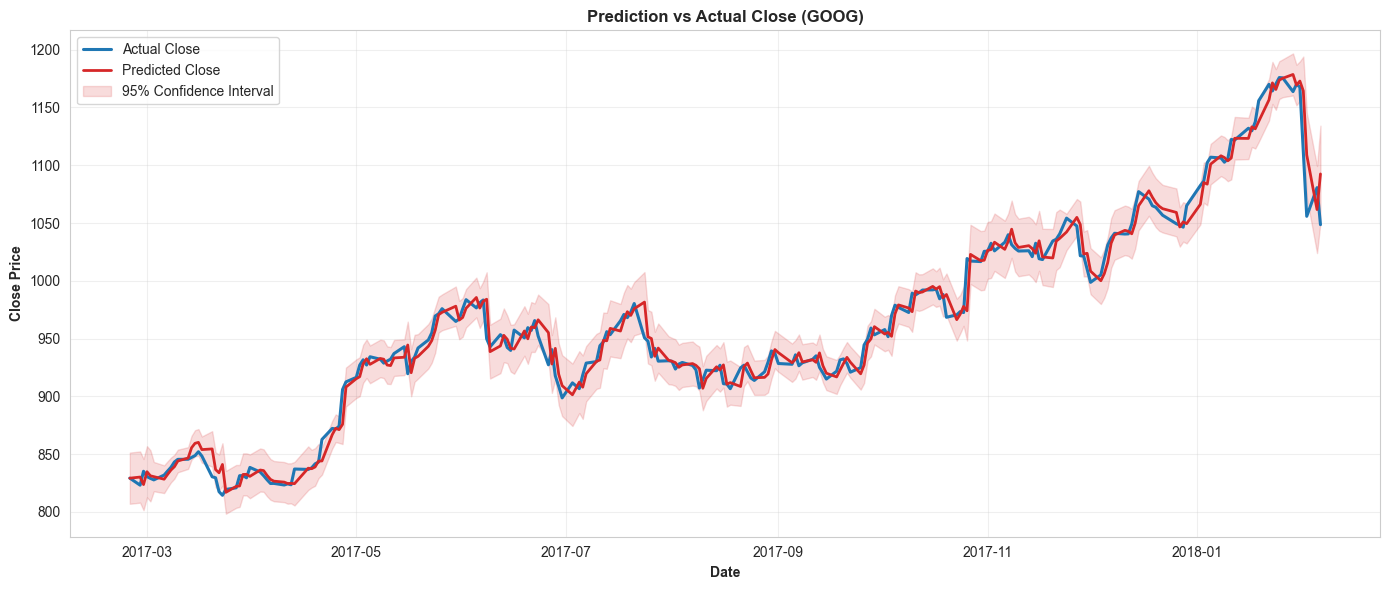

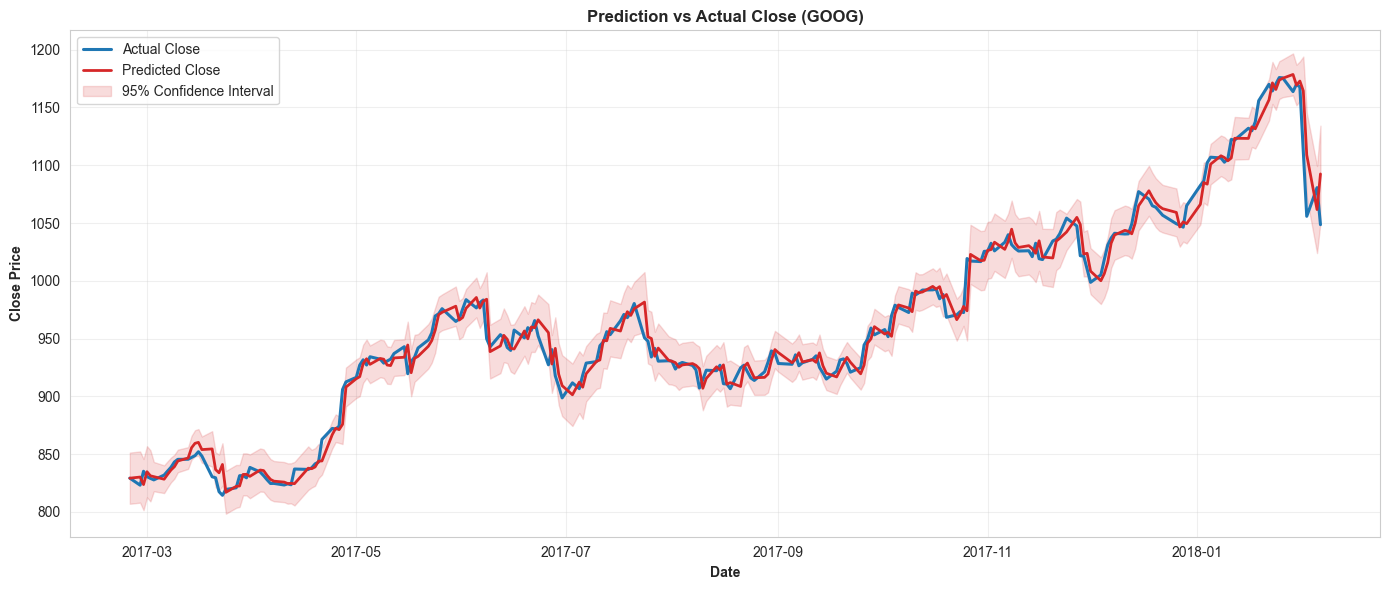

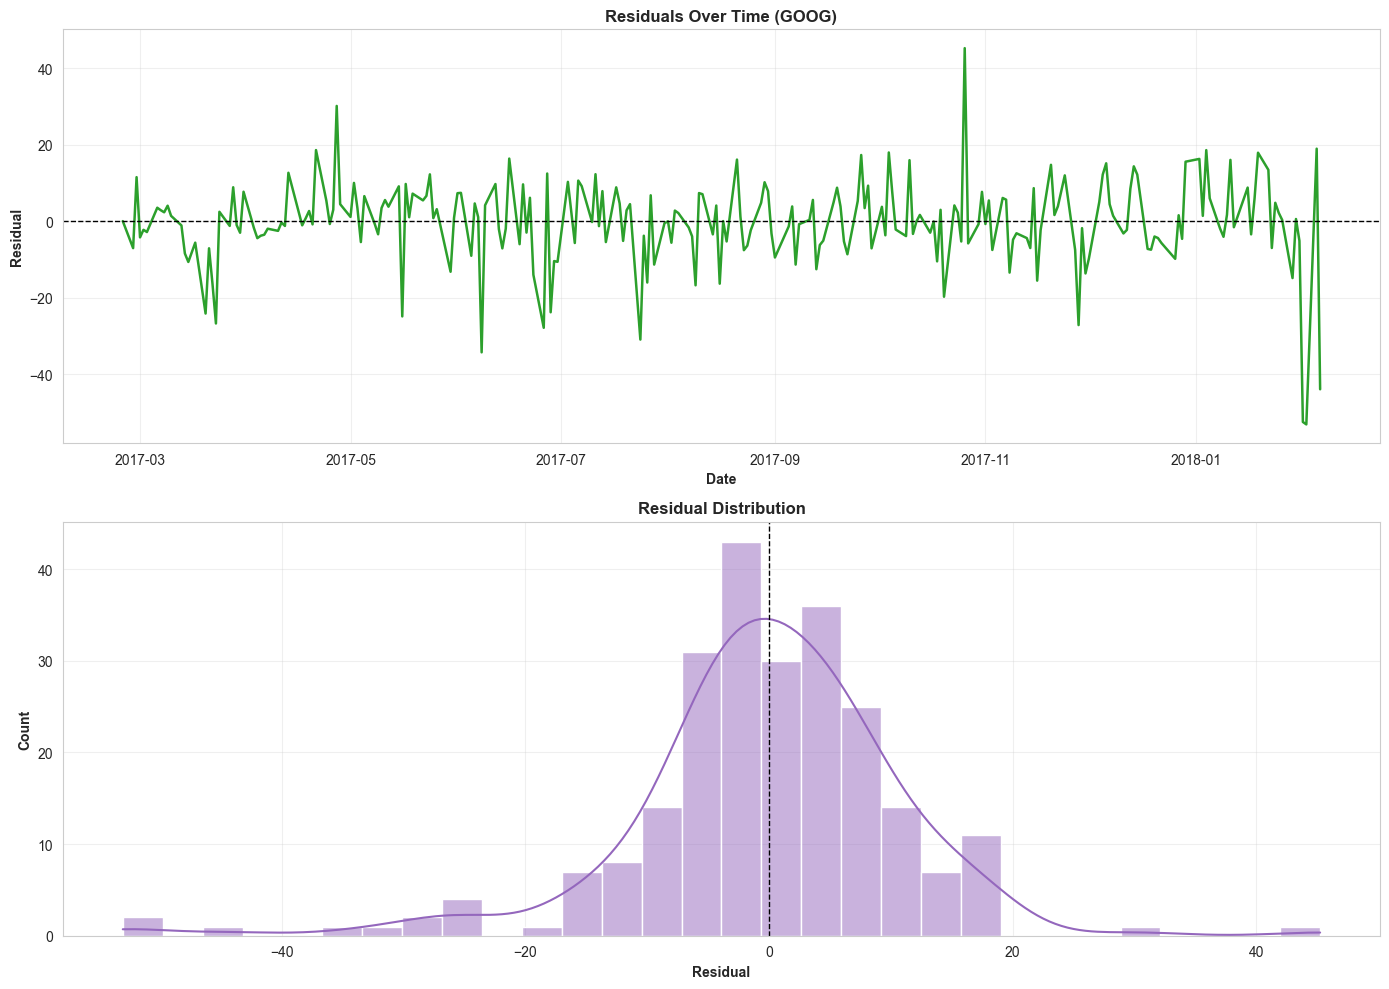

Residual summary:
count    240.000000
mean      -0.385687
std       11.320103
min      -53.057143
25%       -5.153430
50%       -0.030119
75%        5.598718
max       45.229006
dtype: float64
Residual MAE: 7.785573
Residual RMSE: 11.303077


,feature,importance,method
0,direct_sentiment_3d,0.072593,MODEL_IMPORTANCE
1,news_intensity_10d,0.063515,MODEL_IMPORTANCE
2,cluster_news_count_10d,0.061624,MODEL_IMPORTANCE
3,volume_norm,0.060208,MODEL_IMPORTANCE
4,max_cosine_sim_10d,0.059748,MODEL_IMPORTANCE
5,news_count_10d,0.058426,MODEL_IMPORTANCE
6,lag_return_1,0.058062,MODEL_IMPORTANCE
7,lag_return_5,0.057551,MODEL_IMPORTANCE
8,hl_spread,0.056174,MODEL_IMPORTANCE
9,momentum_5,0.049001,MODEL_IMPORTANCE


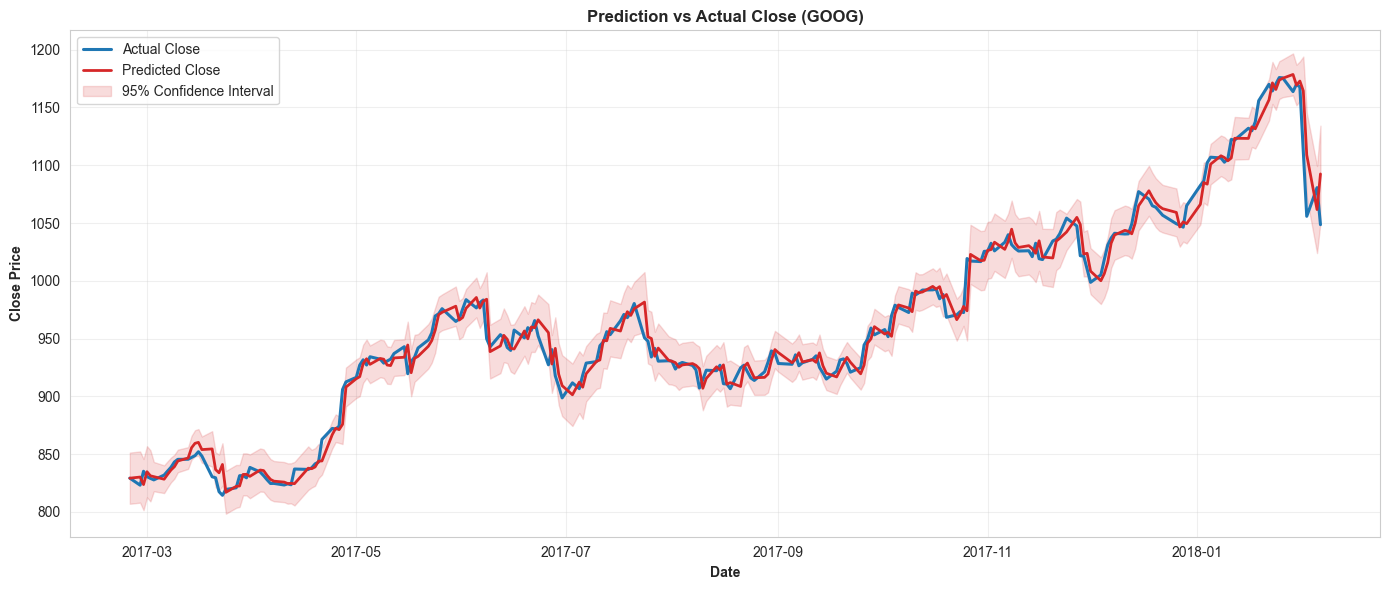

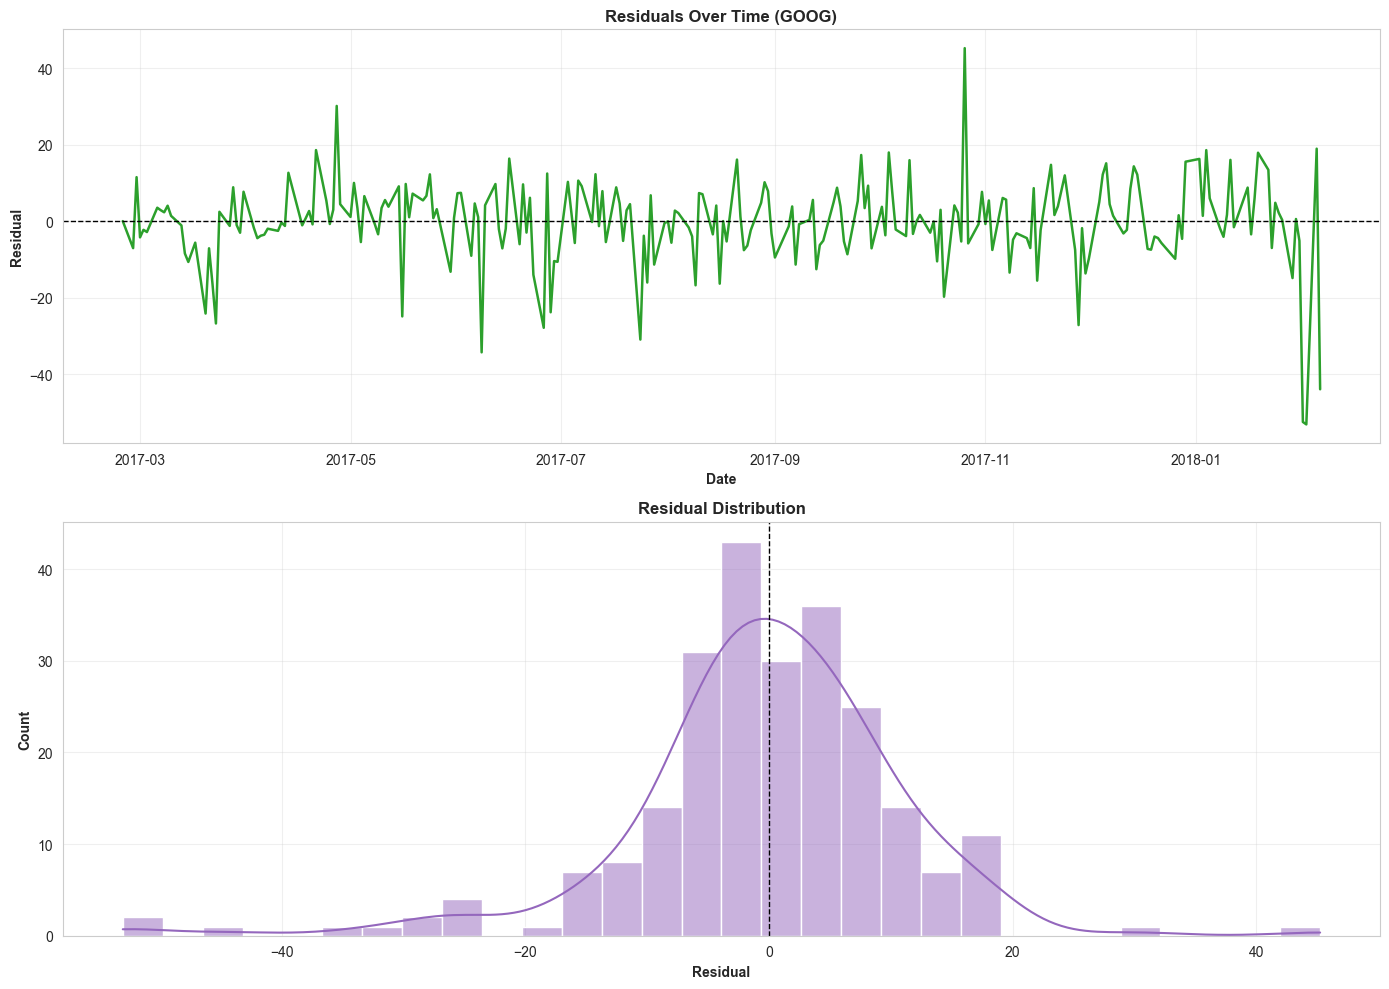

Residual summary:
count    240.000000
mean      -0.385687
std       11.320103
min      -53.057143
25%       -5.153430
50%       -0.030119
75%        5.598718
max       45.229006
dtype: float64
Residual MAE: 7.785573
Residual RMSE: 11.303077


,feature,importance,method
0,direct_sentiment_3d,0.072593,MODEL_IMPORTANCE
1,news_intensity_10d,0.063515,MODEL_IMPORTANCE
2,cluster_news_count_10d,0.061624,MODEL_IMPORTANCE
3,volume_norm,0.060208,MODEL_IMPORTANCE
4,max_cosine_sim_10d,0.059748,MODEL_IMPORTANCE
5,news_count_10d,0.058426,MODEL_IMPORTANCE
6,lag_return_1,0.058062,MODEL_IMPORTANCE
7,lag_return_5,0.057551,MODEL_IMPORTANCE
8,hl_spread,0.056174,MODEL_IMPORTANCE
9,momentum_5,0.049001,MODEL_IMPORTANCE


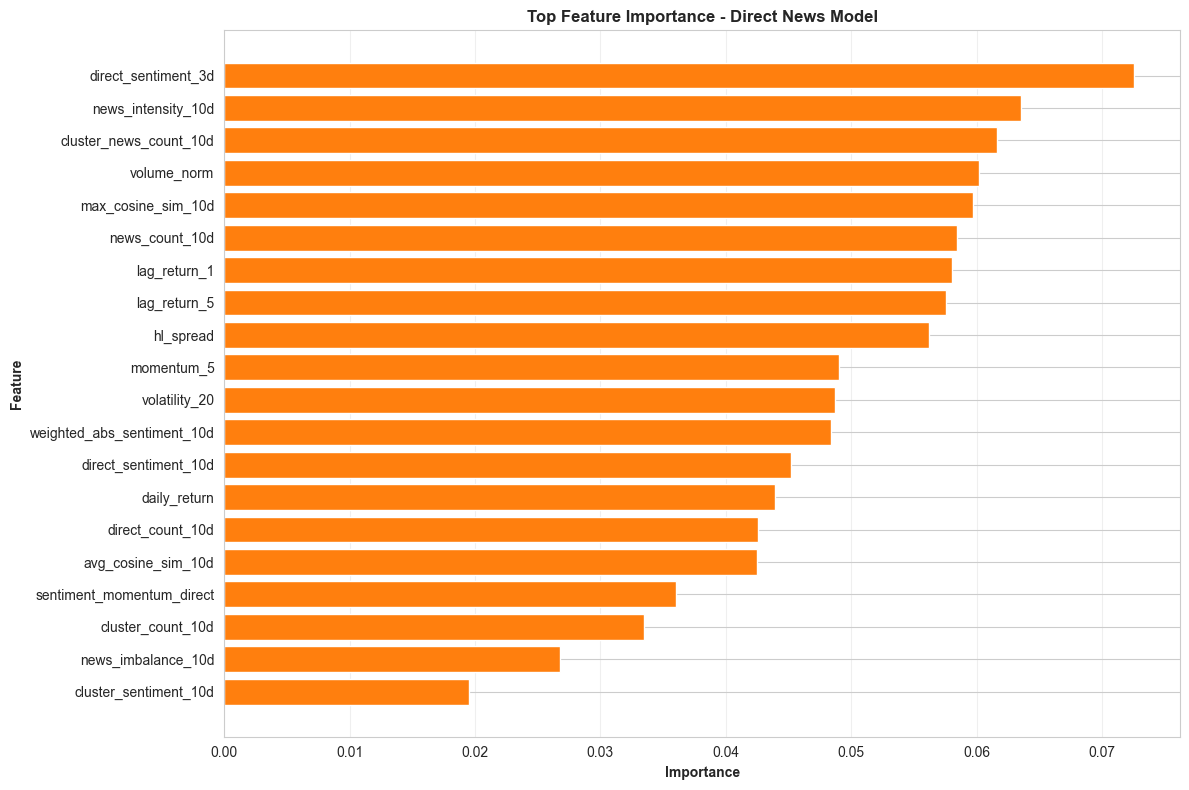

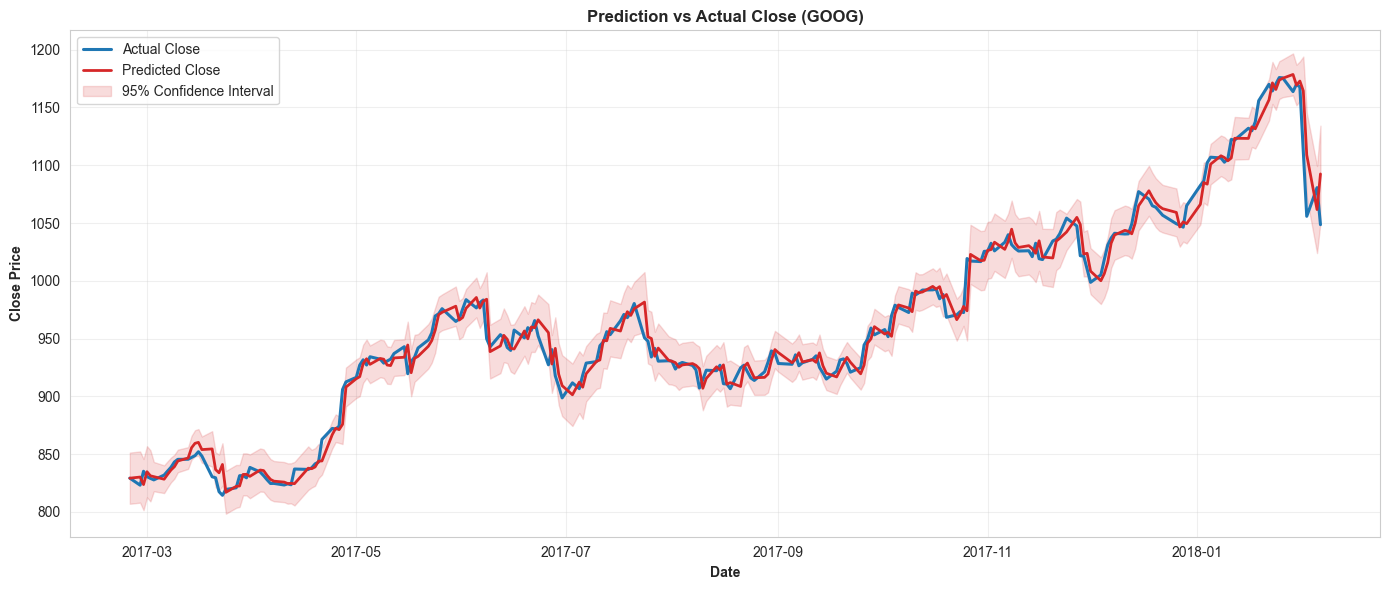

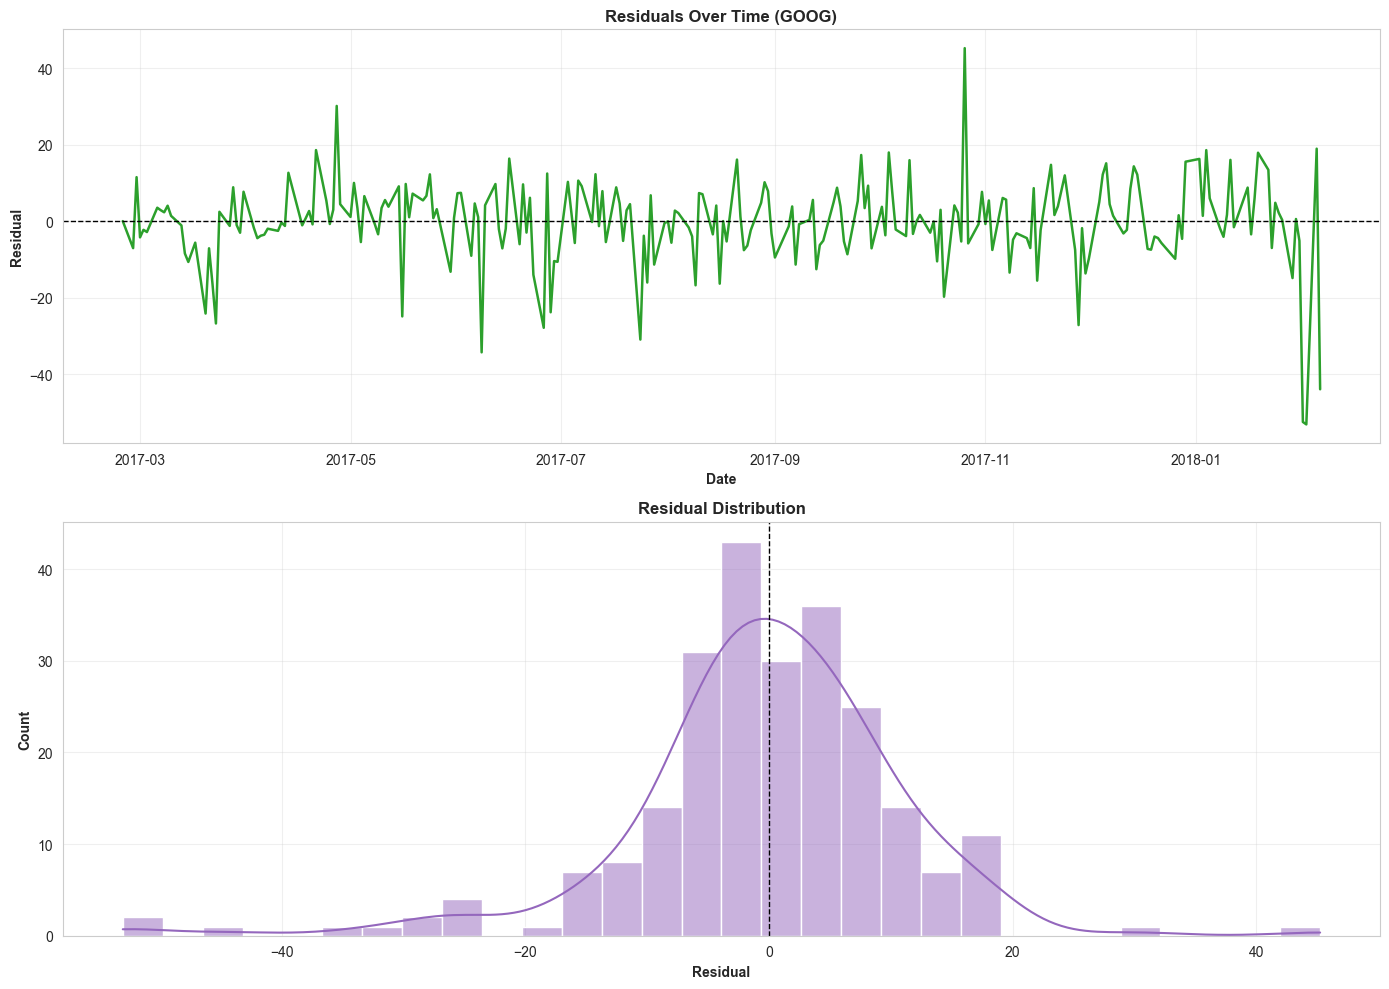

Residual summary:
count    240.000000
mean      -0.385687
std       11.320103
min      -53.057143
25%       -5.153430
50%       -0.030119
75%        5.598718
max       45.229006
dtype: float64
Residual MAE: 7.785573
Residual RMSE: 11.303077


,feature,importance,method
0,direct_sentiment_3d,0.072593,MODEL_IMPORTANCE
1,news_intensity_10d,0.063515,MODEL_IMPORTANCE
2,cluster_news_count_10d,0.061624,MODEL_IMPORTANCE
3,volume_norm,0.060208,MODEL_IMPORTANCE
4,max_cosine_sim_10d,0.059748,MODEL_IMPORTANCE
5,news_count_10d,0.058426,MODEL_IMPORTANCE
6,lag_return_1,0.058062,MODEL_IMPORTANCE
7,lag_return_5,0.057551,MODEL_IMPORTANCE
8,hl_spread,0.056174,MODEL_IMPORTANCE
9,momentum_5,0.049001,MODEL_IMPORTANCE


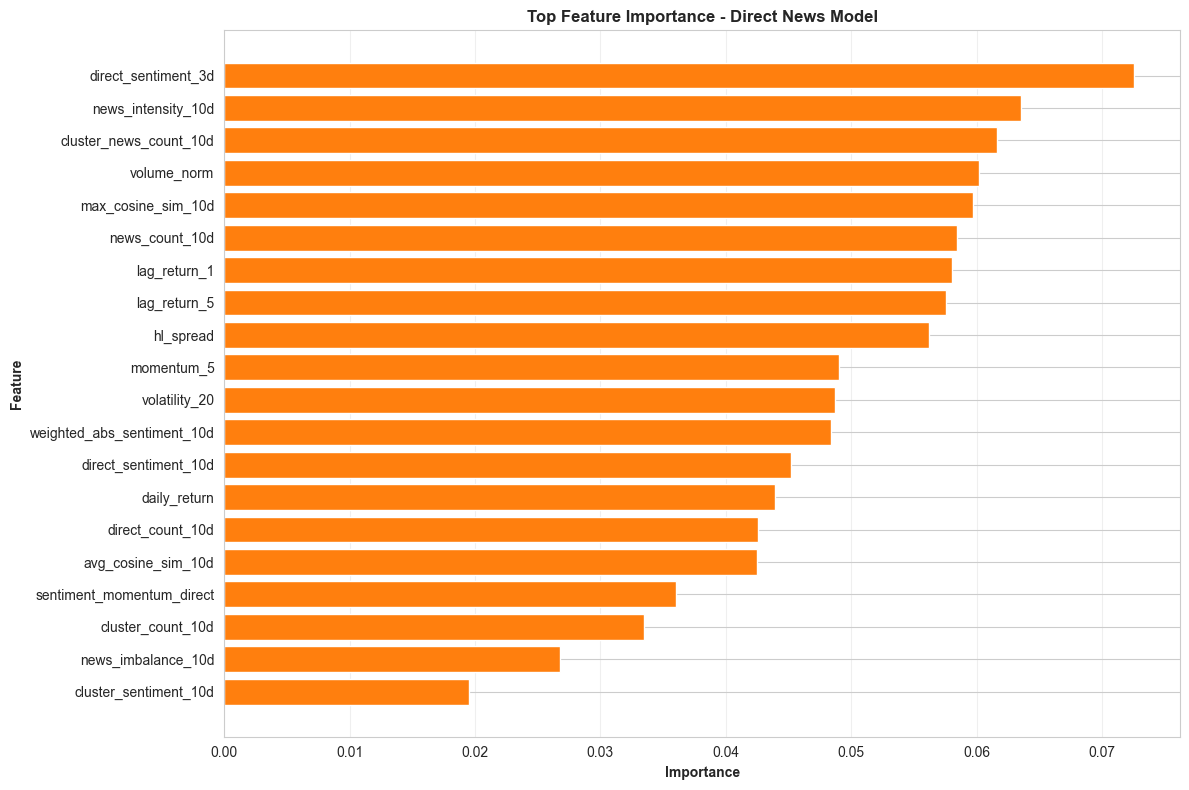

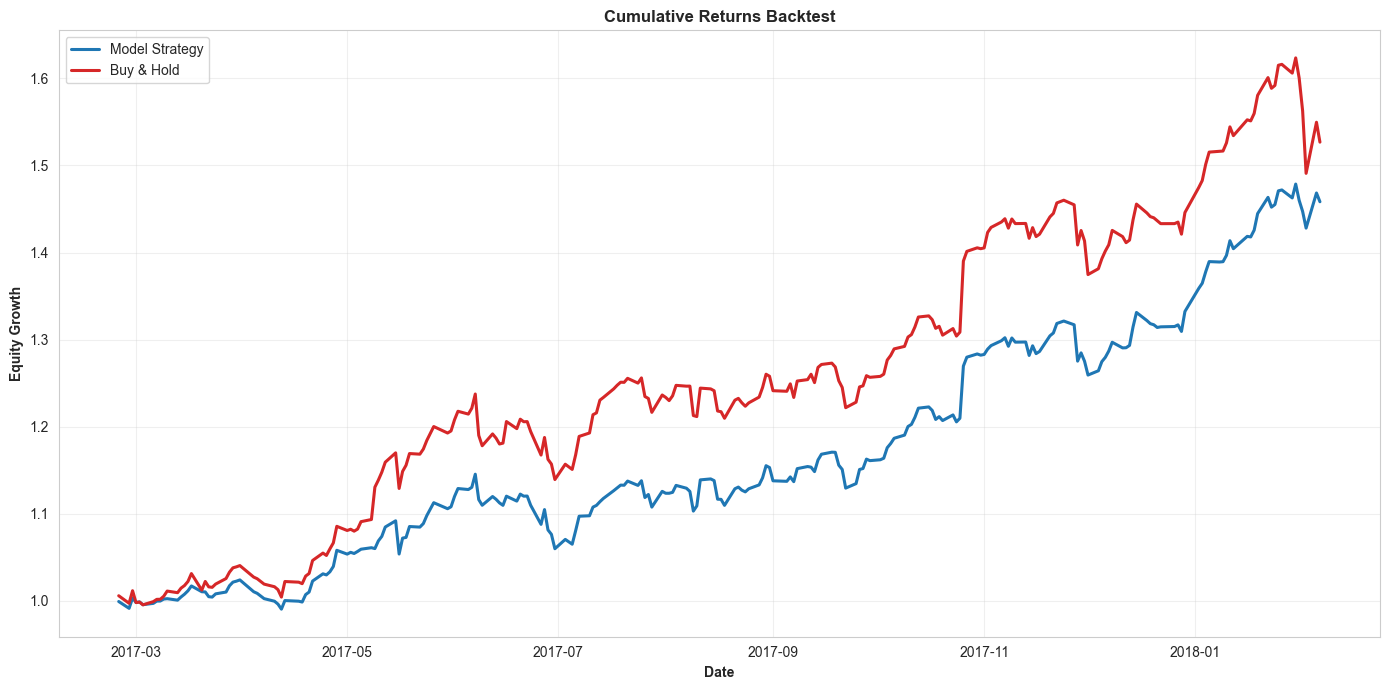

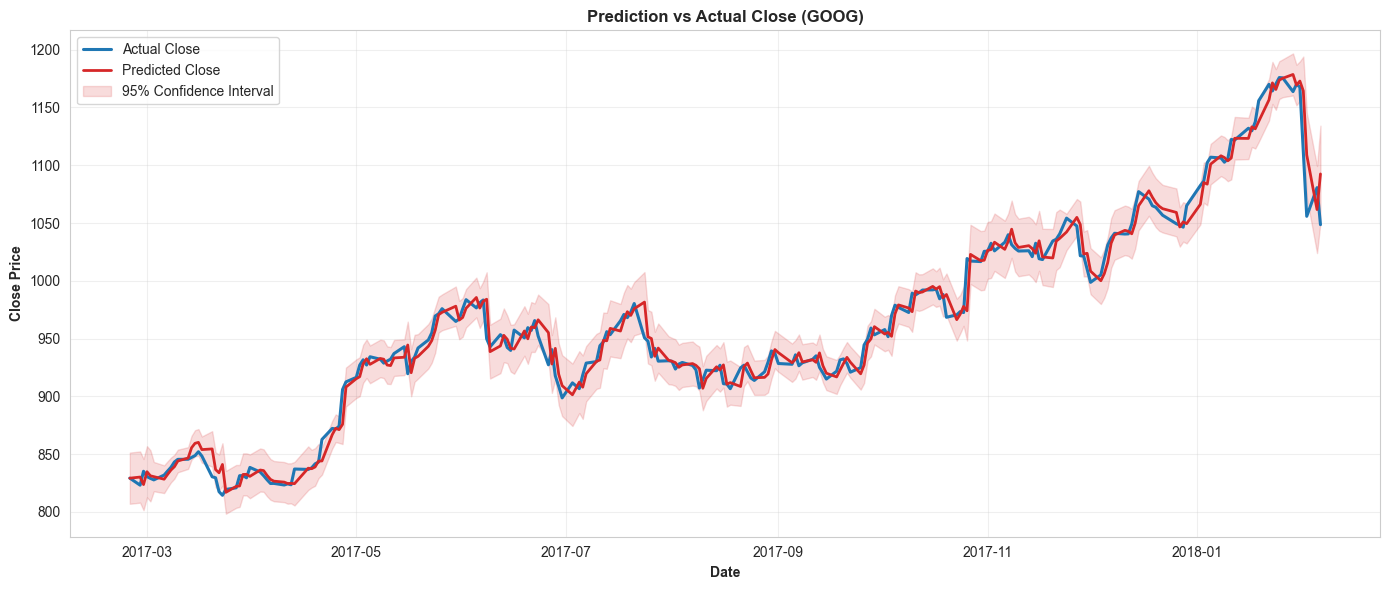

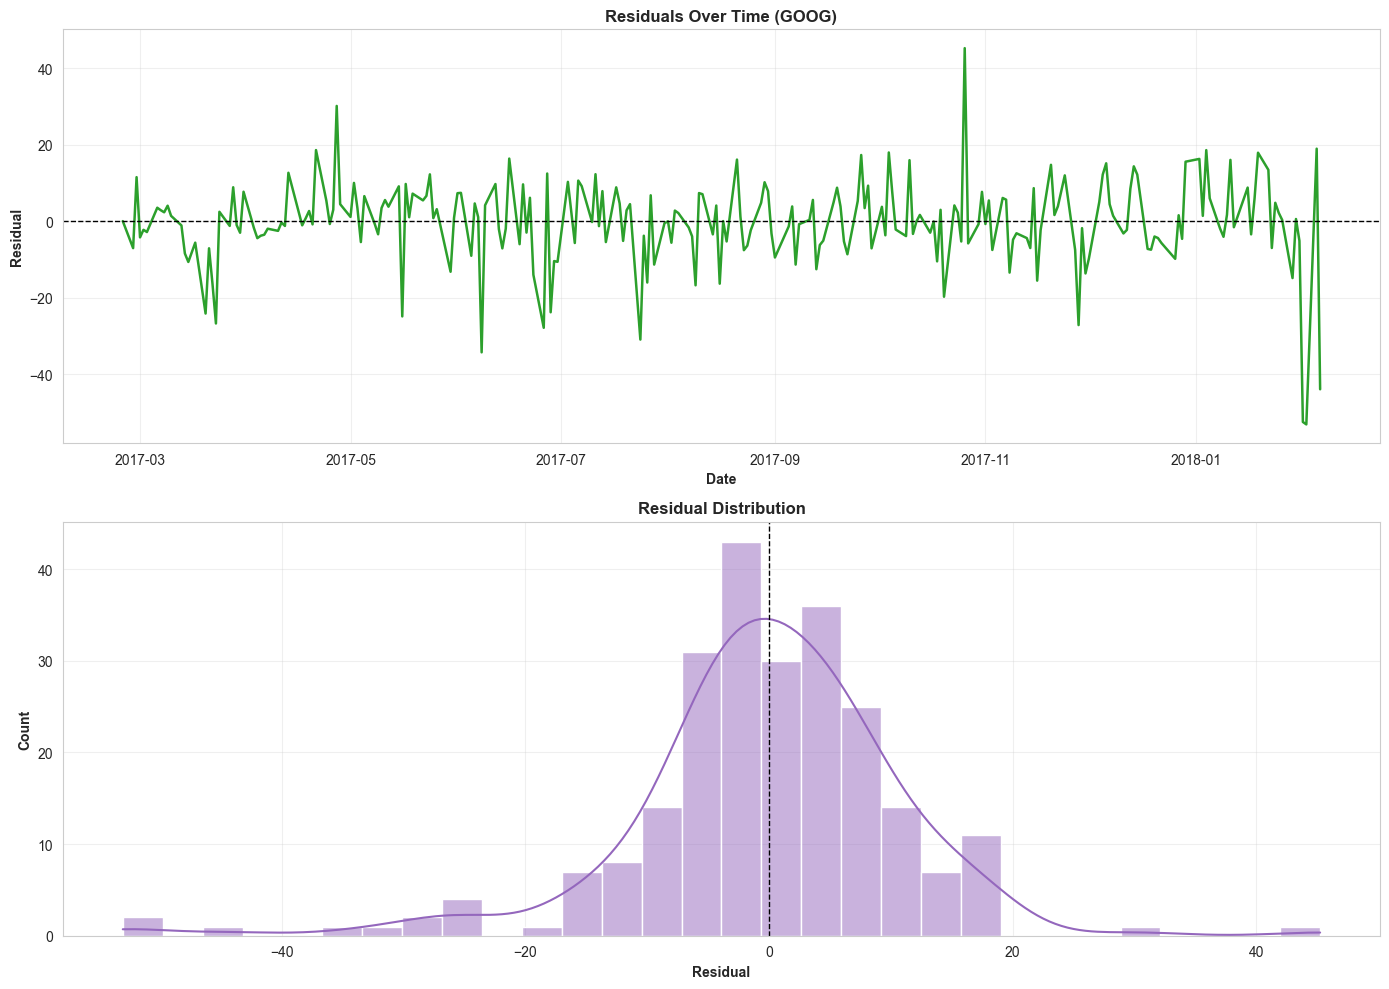

Residual summary:
count    240.000000
mean      -0.385687
std       11.320103
min      -53.057143
25%       -5.153430
50%       -0.030119
75%        5.598718
max       45.229006
dtype: float64
Residual MAE: 7.785573
Residual RMSE: 11.303077


,feature,importance,method
0,direct_sentiment_3d,0.072593,MODEL_IMPORTANCE
1,news_intensity_10d,0.063515,MODEL_IMPORTANCE
2,cluster_news_count_10d,0.061624,MODEL_IMPORTANCE
3,volume_norm,0.060208,MODEL_IMPORTANCE
4,max_cosine_sim_10d,0.059748,MODEL_IMPORTANCE
5,news_count_10d,0.058426,MODEL_IMPORTANCE
6,lag_return_1,0.058062,MODEL_IMPORTANCE
7,lag_return_5,0.057551,MODEL_IMPORTANCE
8,hl_spread,0.056174,MODEL_IMPORTANCE
9,momentum_5,0.049001,MODEL_IMPORTANCE


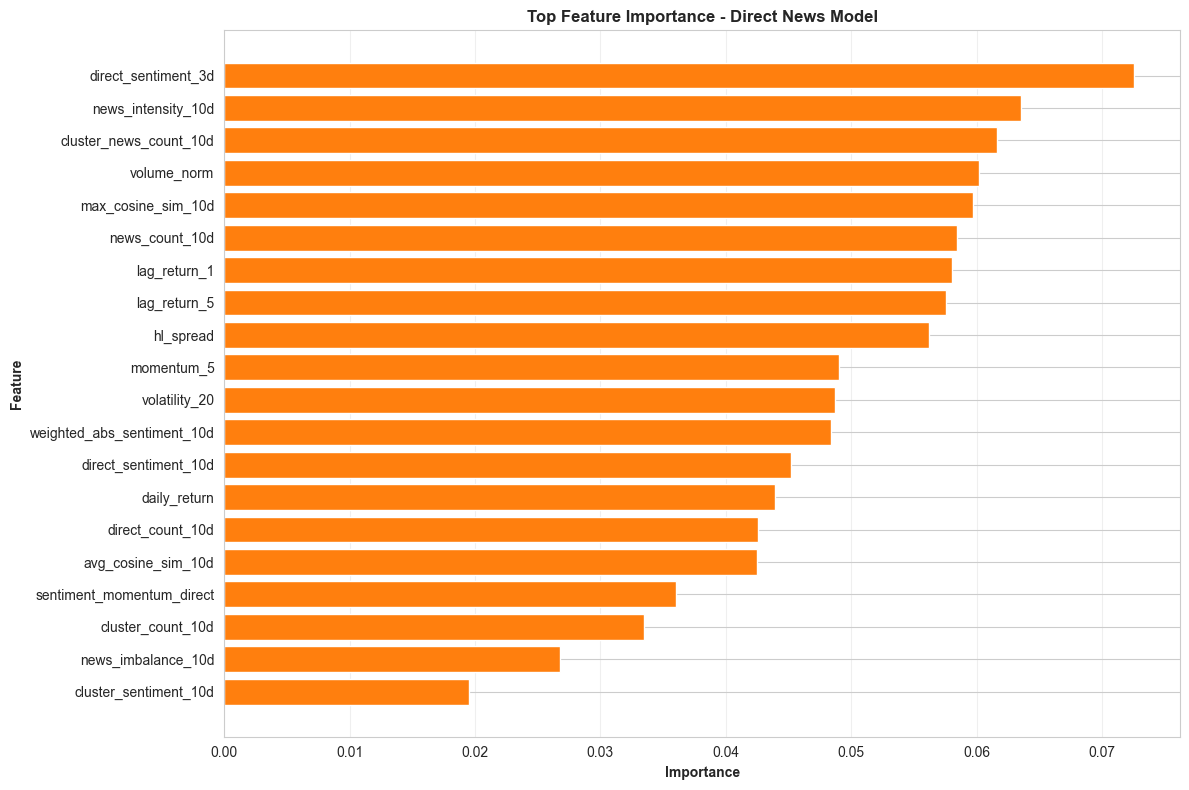

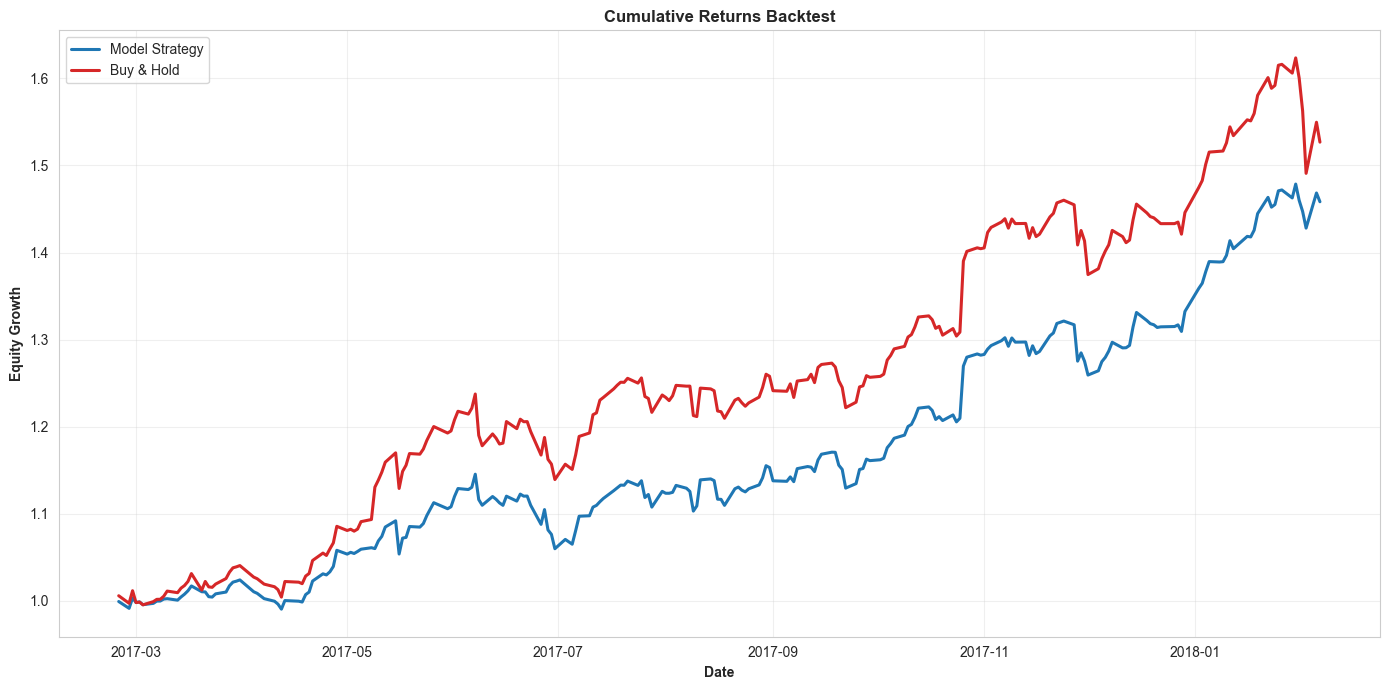

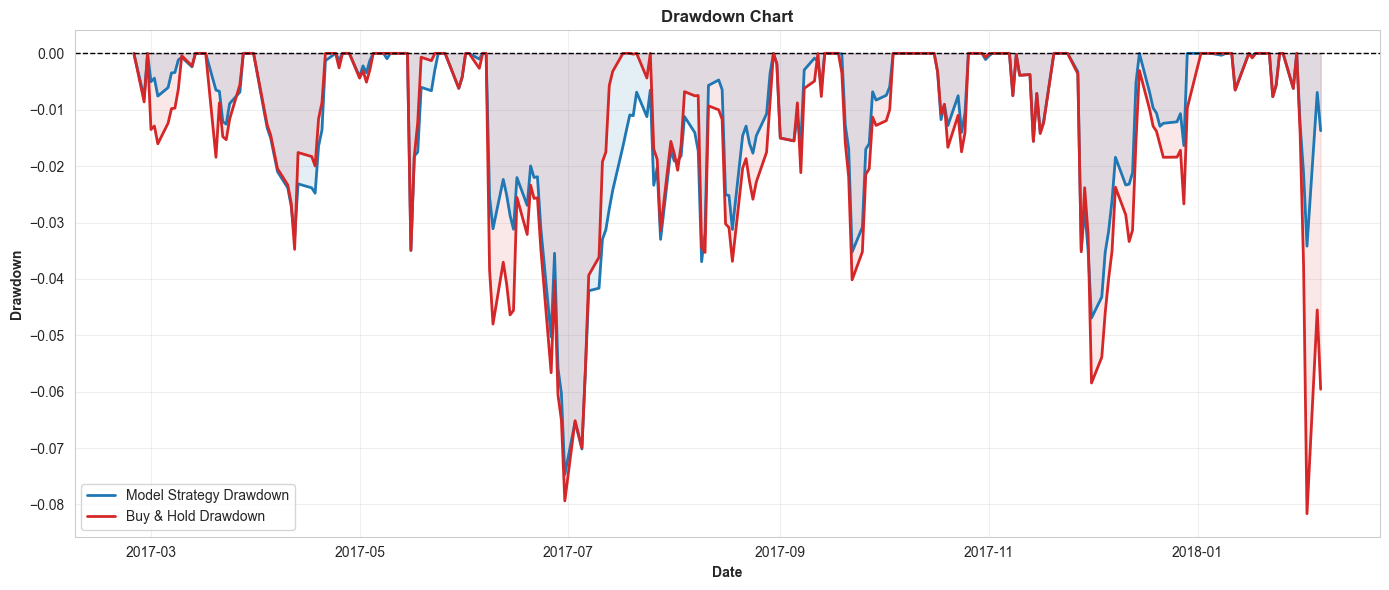

Backtest Metrics
Strategy Sharpe Ratio: 2.8178
Buy & Hold Sharpe Ratio: 2.5440
Strategy Maximum Drawdown: -7.4697%
Buy & Hold Maximum Drawdown: -8.1636%


,Model,Sharpe_Ratio,Max_Drawdown
0,Stacked News Strategy,2.817779,-0.074697
1,Buy & Hold,2.543952,-0.081636


Evaluation stock for price charts: GOOG
Price-chart rows: 240
Portfolio backtest rows (daily): 240


In [51]:
# =========================
# 02D Performance Diagnostics (corrected evaluation design)
# =========================
import importlib.util
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

# -----------------------------------------------------------------------------
# Why this version is different:
# - The previous version mixed multiple stocks into one line chart.
# - That is not a valid price-time series view.
# - Here we evaluate one selected stock for close-price style charts.
# - For backtest, we aggregate signals daily across all stocks as an equal-weight portfolio.
# -----------------------------------------------------------------------------

# Current notebook variables used here:
#   test_df, pred_stack_close, pred_stack_ret, pred_base_close, pred_news_close
#   model_stack, model_news, base_features, news_features, stack_features

# Build a full evaluation frame aligned row-by-row with test_df.
eval_df = test_df[['date', 'Name', 'close', 'target', 'target_return']].copy().reset_index(drop=True)
eval_df['actual_close'] = eval_df['target']
eval_df['pred_close'] = np.asarray(pred_stack_close).reshape(-1)
eval_df['pred_return'] = np.asarray(pred_stack_ret).reshape(-1)

if 'pred_base_close' in globals():
    eval_df['pred_close_base'] = np.asarray(pred_base_close).reshape(-1)
if 'pred_news_close' in globals():
    eval_df['pred_close_news'] = np.asarray(pred_news_close).reshape(-1)
if 'pred_base_ret' in globals():
    eval_df['pred_return_base'] = np.asarray(pred_base_ret).reshape(-1)
if 'pred_news_ret' in globals():
    eval_df['pred_return_news'] = np.asarray(pred_news_ret).reshape(-1)

# Pick one stock for line charts so the x-axis is meaningful.
eval_symbol = 'GOOG' if 'GOOG' in set(eval_df['Name']) else str(eval_df['Name'].iloc[0])
stock_df = eval_df[eval_df['Name'] == eval_symbol].copy().sort_values('date').reset_index(drop=True)

# Return-based trading signal.
stock_df['signal'] = (stock_df['pred_return'] > 0).astype(int)
stock_df['strategy_return'] = stock_df['signal'] * stock_df['target_return']
stock_df['buy_hold_return'] = stock_df['target_return']

# For backtest, use equal-weight daily aggregation across the whole test universe.
portfolio_df = eval_df.copy()
portfolio_df['signal'] = (portfolio_df['pred_return'] > 0).astype(int)
portfolio_df['strategy_return'] = portfolio_df['signal'] * portfolio_df['target_return']
portfolio_df['buy_hold_return'] = portfolio_df['target_return']
portfolio_daily = portfolio_df.groupby('date', as_index=False).agg(
    strategy_return=('strategy_return', 'mean'),
    buy_hold_return=('buy_hold_return', 'mean')
).sort_values('date').reset_index(drop=True)

# --- Metrics helpers ---
def calc_sharpe_ratio(returns, periods_per_year=252, risk_free_rate=0.0):
    returns = pd.Series(returns).dropna()
    if len(returns) == 0:
        return np.nan
    excess = returns - risk_free_rate / periods_per_year
    std = excess.std(ddof=0)
    if std == 0 or np.isnan(std):
        return np.nan
    return np.sqrt(periods_per_year) * excess.mean() / std


def calc_max_drawdown(equity_curve):
    equity_curve = pd.Series(equity_curve).dropna()
    running_max = equity_curve.cummax()
    drawdown = equity_curve / running_max - 1.0
    return float(drawdown.min()), drawdown


# --- 1) Prediction vs Actual for one stock with 95% CI ---
def plot_prediction_vs_actual(df, date_col='date', actual_col='actual_close', pred_col='pred_close', ci_window=20, title_suffix=''):
    df = df.copy().sort_values(date_col)
    residual = df[actual_col] - df[pred_col]
    rolling_std = residual.rolling(ci_window, min_periods=max(5, ci_window // 3)).std()
    rolling_std = rolling_std.fillna(residual.std(ddof=0))
    ci = 1.96 * rolling_std

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(df[date_col], df[actual_col], label='Actual Close', linewidth=2.2, color='#1f77b4')
    ax.plot(df[date_col], df[pred_col], label='Predicted Close', linewidth=2.0, color='#d62728')
    ax.fill_between(
        df[date_col],
        df[pred_col] - ci,
        df[pred_col] + ci,
        color='#d62728',
        alpha=0.16,
        label='95% Confidence Interval'
    )
    ax.set_title(f'Prediction vs Actual Close {title_suffix}'.strip())
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --- 2) Residual analysis for one stock ---
def plot_residual_analysis(df, date_col='date', actual_col='actual_close', pred_col='pred_close', title_suffix=''):
    df = df.copy().sort_values(date_col)
    residual = df[actual_col] - df[pred_col]

    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1]})

    axes[0].plot(df[date_col], residual, color='#2ca02c', linewidth=1.8)
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_title(f'Residuals Over Time {title_suffix}'.strip())
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Residual')
    axes[0].grid(True, alpha=0.3)

    sns.histplot(residual, bins=30, kde=True, ax=axes[1], color='#9467bd')
    axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_title('Residual Distribution')
    axes[1].set_xlabel('Residual')
    axes[1].set_ylabel('Count')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print('Residual summary:')
    print(residual.describe())
    print(f'Residual MAE: {np.mean(np.abs(residual)):.6f}')
    print(f'Residual RMSE: {np.sqrt(np.mean(residual**2)):.6f}')


# --- 3) Feature importance ---
def get_feature_importance_df(model, feature_names, X_test=None, use_shap=True, max_sample=2000):
    feature_names = list(feature_names)

    if use_shap and X_test is not None:
        shap_available = importlib.util.find_spec('shap') is not None
        if shap_available:
            try:
                shap = importlib.import_module('shap')

                sample_X = X_test
                if hasattr(X_test, 'shape') and X_test.shape[0] > max_sample:
                    sample_idx = np.random.choice(X_test.shape[0], max_sample, replace=False)
                    sample_X = X_test[sample_idx]

                explainer = shap.TreeExplainer(model)
                shap_values = explainer.shap_values(sample_X)
                if isinstance(shap_values, list):
                    shap_values = shap_values[0]

                importance = np.abs(shap_values).mean(axis=0)
                out = pd.DataFrame({'feature': feature_names, 'importance': importance})
                out = out.sort_values('importance', ascending=False).reset_index(drop=True)
                out['method'] = 'SHAP'
                return out
            except Exception as e:
                print(f'SHAP unavailable, fallback to built-in importances. Reason: {e}')

    # Use model.feature_importances_ first because XGBoost may store internal names f0, f1, ...
    if hasattr(model, 'feature_importances_'):
        importance = np.asarray(model.feature_importances_, dtype=float)
        if len(importance) == len(feature_names) and np.any(importance > 0):
            out = pd.DataFrame({'feature': feature_names, 'importance': importance})
            out = out.sort_values('importance', ascending=False).reset_index(drop=True)
            out['method'] = 'MODEL_IMPORTANCE'
            return out

    booster = model.get_booster()
    score_map = booster.get_score(importance_type='gain')
    if len(score_map) == 0:
        score_map = booster.get_score(importance_type='weight')

    importance = []
    for idx, name in enumerate(feature_names):
        key_name = f'f{idx}'
        importance.append(float(score_map.get(name, score_map.get(key_name, 0.0))))

    out = pd.DataFrame({'feature': feature_names, 'importance': importance})
    out = out.sort_values('importance', ascending=False).reset_index(drop=True)
    out['method'] = 'GAIN'
    return out



def plot_feature_importance(imp_df, top_n=20, title='Top Feature Importance'):
    imp_df = imp_df.head(top_n).copy().sort_values('importance', ascending=True)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(imp_df['feature'], imp_df['importance'], color='#ff7f0e')
    ax.set_title(title)
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


# --- 4) Backtest / drawdown ---
def plot_backtest(df, date_col='date'):
    df = df.copy().sort_values(date_col).reset_index(drop=True)
    initial_capital = 1.0

    df['strategy_equity'] = initial_capital * (1 + df['strategy_return'].fillna(0)).cumprod()
    df['buy_hold_equity'] = initial_capital * (1 + df['buy_hold_return'].fillna(0)).cumprod()

    strategy_mdd, strategy_dd = calc_max_drawdown(df['strategy_equity'])
    buyhold_mdd, buyhold_dd = calc_max_drawdown(df['buy_hold_equity'])

    strategy_sharpe = calc_sharpe_ratio(df['strategy_return'])
    buyhold_sharpe = calc_sharpe_ratio(df['buy_hold_return'])

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(df[date_col], df['strategy_equity'], label='Model Strategy', linewidth=2.2, color='#1f77b4')
    ax.plot(df[date_col], df['buy_hold_equity'], label='Buy & Hold', linewidth=2.2, color='#d62728')
    ax.set_title('Cumulative Returns Backtest')
    ax.set_xlabel('Date')
    ax.set_ylabel('Equity Growth')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(df[date_col], strategy_dd, label='Model Strategy Drawdown', linewidth=2.0, color='#1f77b4')
    ax.plot(df[date_col], buyhold_dd, label='Buy & Hold Drawdown', linewidth=2.0, color='#d62728')
    ax.fill_between(df[date_col], strategy_dd, 0, color='#1f77b4', alpha=0.12)
    ax.fill_between(df[date_col], buyhold_dd, 0, color='#d62728', alpha=0.10)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title('Drawdown Chart')
    ax.set_xlabel('Date')
    ax.set_ylabel('Drawdown')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('Backtest Metrics')
    print(f'Strategy Sharpe Ratio: {strategy_sharpe:.4f}')
    print(f'Buy & Hold Sharpe Ratio: {buyhold_sharpe:.4f}')
    print(f'Strategy Maximum Drawdown: {strategy_mdd:.4%}')
    print(f'Buy & Hold Maximum Drawdown: {buyhold_mdd:.4%}')

    return {
        'strategy_sharpe': strategy_sharpe,
        'buyhold_sharpe': buyhold_sharpe,
        'strategy_max_drawdown': strategy_mdd,
        'buyhold_max_drawdown': buyhold_mdd,
        'backtest_frame': df,
    }


# =========================
# Run diagnostics on current 02D outputs
# =========================
plot_prediction_vs_actual(stock_df, date_col='date', actual_col='actual_close', pred_col='pred_close', ci_window=20, title_suffix=f'({eval_symbol})')
plot_residual_analysis(stock_df, date_col='date', actual_col='actual_close', pred_col='pred_close', title_suffix=f'({eval_symbol})')

# Use the direct-news model if available for interpretable feature importance.
if 'model_news' in globals() and 'X_test_news' in globals():
    importance_model = model_news
    importance_features = base_features + news_features
    importance_X = X_test_news
    importance_title = 'Top Feature Importance - Direct News Model'
elif 'model_stack' in globals() and 'X_test_stack' in globals():
    importance_model = model_stack
    importance_features = stack_features
    importance_X = X_test_stack
    importance_title = 'Top Feature Importance - Stacked Residual Model'
else:
    importance_model = None

if importance_model is not None:
    imp_df = get_feature_importance_df(
        model=importance_model,
        feature_names=importance_features,
        X_test=importance_X,
        use_shap=True
    )
    display(imp_df.head(20))
    plot_feature_importance(imp_df, top_n=20, title=importance_title)

bt_result = plot_backtest(portfolio_daily, date_col='date')

perf_summary = pd.DataFrame([
    {
        'Model': 'Stacked News Strategy',
        'Sharpe_Ratio': bt_result['strategy_sharpe'],
        'Max_Drawdown': bt_result['strategy_max_drawdown'],
    },
    {
        'Model': 'Buy & Hold',
        'Sharpe_Ratio': bt_result['buyhold_sharpe'],
        'Max_Drawdown': bt_result['buyhold_max_drawdown'],
    }
])
display(perf_summary)

print(f'Evaluation stock for price charts: {eval_symbol}')
print(f'Price-chart rows: {len(stock_df):,}')
print(f'Portfolio backtest rows (daily): {len(portfolio_daily):,}')